In [1]:
import pandas as pd

In [2]:
ABS_yield_path = '/g/data/w97/mg5624/ABS_project/yield_model_analytics/performance_scores/state_aggregated/all_temp_and_hyd/full_season_only/single_drought_180/'
ABARES_yield_path = '/g/data/w97/mg5624/ABS_project/ABARES/'

In [ ]:
model_yield_path = '/g/data/w97/mg5624/ABS_project/yield_model_analytics/modelled_yield/past_yield/all_states_modelled_annual_avg_yield.csv'
model_yield = pd.read_csv(model_yield_path)
model_yield_sorted = model_yield.pivot(index='year', columns='state', values='predicted_yield').reset_index()

In [4]:
dfs = []
for state in ['AUS', 'NSW', 'QLD', 'VIC', 'SA', 'WA']:
    ABS_yield_file = ABS_yield_path + f'RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
    ABS_yield = pd.read_csv(ABS_yield_file)
    ABS_yield = ABS_yield[ABS_yield['seed']==0][['year', 'True']]
    ABS_yield = ABS_yield.rename(columns={'True': state})
    dfs.append(ABS_yield)

# Merge all on 'year'
ABS_df = dfs[0]
for df in dfs[1:]:
    ABS_df = ABS_df.merge(df, on='year')

In [5]:
ABS_df

,year,AUS,NSW,QLD,VIC,SA,WA
0,2001,0.055519,0.367636,-0.414446,0.750267,0.393868,-0.715695
1,2002,0.452271,0.539423,-0.270162,0.630344,0.856041,0.225710
2,2003,-1.087210,-0.949340,-0.740181,-1.256521,-1.103417,-1.241177
3,2004,0.333656,0.082842,-0.128322,0.399206,-0.016767,0.895330
4,2005,-0.167703,0.009988,0.116388,-0.500571,-0.684619,-0.035972
5,2006,0.334368,0.427315,-0.158383,0.378210,0.200205,0.407908
6,2007,-1.007484,-0.970947,-0.627157,-1.417084,-1.539597,-0.694833
7,2008,-0.720567,-1.080343,-0.228706,-0.593371,-0.982300,-0.361377
8,2009,-0.239016,-0.190538,0.568069,-0.828598,-0.873437,0.084841
9,2010,-0.234580,-0.451903,-0.139016,-0.233471,0.151148,-0.200012


In [6]:
twentieth_cent_data_path = '/g/data/w97/mg5624/ABS_project/twentieth_cent_crop/'
twent_cent_df = pd.read_csv(twentieth_cent_data_path + 'aus_data_sorted.csv', index_col=0)
twent_cent_df = twent_cent_df[twent_cent_df['Year'] > 1965]
twent_cent_df = twent_cent_df[twent_cent_df['Year'] < 2018]
twent_cent_df = twent_cent_df.rename(columns={'Year':'year'})
twent_cent_df['AUS'] = twent_cent_df[['NSW', 'QLD', 'SA', 'VIC', 'WA']].mean(axis=1)
twent_cent_df.head()

,year,NSW,QLD,SA,VIC,WA,AUS
101,1966,0.574807,1.228238,0.978934,1.325563,1.116442,1.044797
102,1967,1.908641,1.956714,1.221870,1.519411,1.092859,1.539899
103,1968,0.714844,1.247825,0.631266,0.590711,1.081673,0.853264
104,1969,1.452250,1.578337,1.491101,1.531477,1.036006,1.417834
105,1970,1.269609,0.665681,1.238722,1.703401,0.660406,1.107564


In [7]:
from sklearn.preprocessing import StandardScaler

states = ['AUS', 'NSW', 'QLD', 'SA', 'VIC', 'WA']

# Fit scaler on 2001-2017 period only
ref_period = twent_cent_df[(twent_cent_df['year'] >= 2001) & (twent_cent_df['year'] <= 2017)]
scaler = StandardScaler()
scaler.fit(ref_period[states])

# Apply to full dataframe
twent_cent_df[states] = scaler.transform(twent_cent_df[states])

## Comaprison of Twent Cent and ABS Data

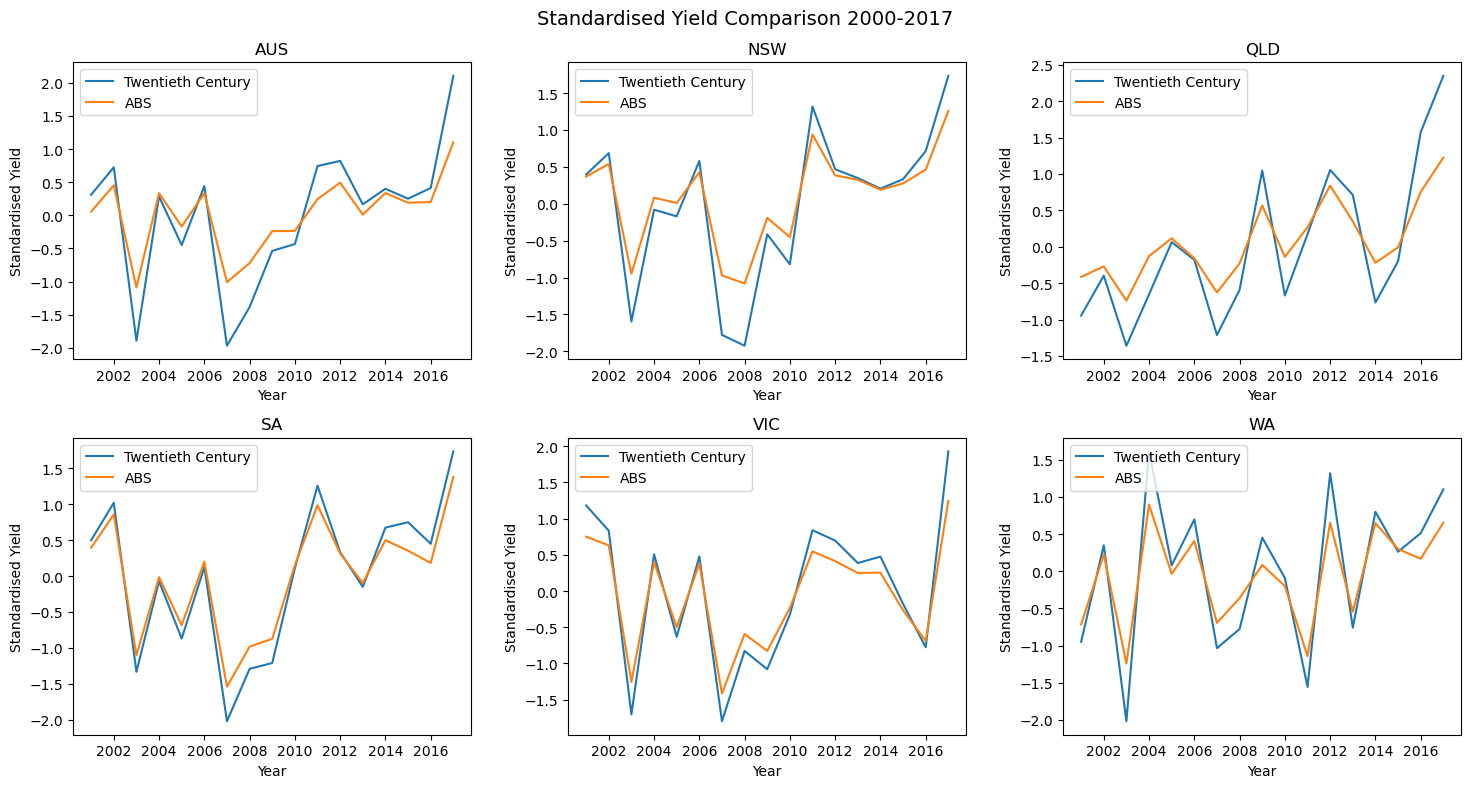

In [8]:
import matplotlib.pyplot as plt

states = ['AUS', 'NSW', 'QLD', 'SA', 'VIC', 'WA']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, state in enumerate(states):
    ax = axes[i]
    
    # Filter to 2000-2017
    df1_plot = twent_cent_df[(twent_cent_df['year'] >= 2001) & (twent_cent_df['year'] <= 2017)]
    df2_plot = ABS_df[(ABS_df['year'] >= 2001) & (ABS_df['year'] <= 2017)]
    
    ax.plot(df1_plot['year'], df1_plot[state], label='Twentieth Century')
    ax.plot(df2_plot['year'], df2_plot[state], label='ABS')
    
    ax.set_title(state)
    ax.set_xlabel('Year')
    ax.set_ylabel('Standardised Yield')
    ax.legend()

plt.suptitle('Standardised Yield Comparison 2000-2017', fontsize=14)
plt.tight_layout()
plt.savefig('yield_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Combine the two df

In [9]:
twent_cent_subset = twent_cent_df[(twent_cent_df['year'] >= 1966)]
ABS_subset = ABS_df[ABS_df['year'] >= 2001]

combined_df = pd.concat([twent_cent_subset, ABS_subset]).reset_index(drop=True)
combined_df.to_csv(twentieth_cent_data_path + 'ABS_twent_cent_yield_1966-2020.csv')

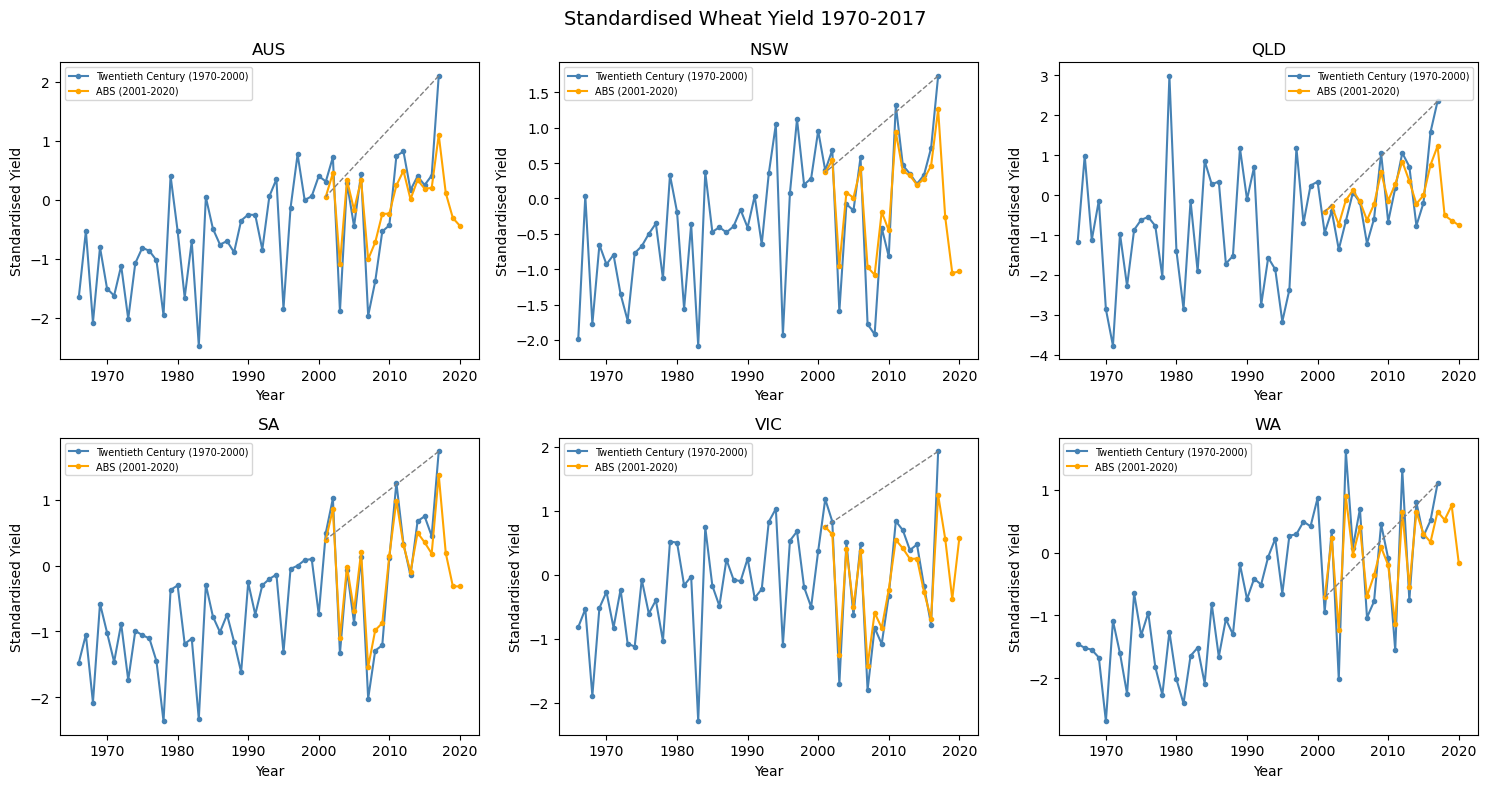

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, state in enumerate(states):
    ax = axes[i]
    
    ax.plot(twent_cent_subset['year'], twent_cent_subset[state], 
            color='steelblue', marker='o', markersize=3, label='Twentieth Century (1970-2000)')
    ax.plot(ABS_subset['year'], ABS_subset[state], 
            color='orange', marker='o', markersize=3, label='ABS (2001-2020)')
    join_years = [twent_cent_subset['year'].iloc[-1], ABS_subset['year'].iloc[0]]
    join_vals = [twent_cent_subset[state].iloc[-1], ABS_subset[state].iloc[0]]
    ax.plot(join_years, join_vals, color='gray', linestyle='--', linewidth=1)
    
    ax.set_title(state)
    ax.set_xlabel('Year')
    ax.set_ylabel('Standardised Yield')
    ax.legend(fontsize=7)


plt.suptitle('Standardised Wheat Yield 1970-2017', fontsize=14)
plt.tight_layout()
plt.savefig('yield_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
twent_cent_subset.head()

,year,NSW,QLD,SA,VIC,WA,AUS
101,1966,-1.989334,-1.180673,-1.472673,-0.817247,-1.454522,-1.648432
102,1967,0.039354,0.988644,-1.048352,-0.534330,-1.518271,-0.529082
103,1968,-1.776345,-1.122347,-2.079926,-1.889748,-1.548511,-2.081459
104,1969,-0.654792,-0.138121,-0.578101,-0.516720,-1.671960,-0.805052
105,1970,-0.932579,-2.855903,-1.018917,-0.265800,-2.687302,-1.506526


# Plot Observed Yield Against Modelled Yield

In [12]:
def bootstrap_theilsen_yuewang(df, n_boot=1000, time_col="time", value_col="value",
                                block=False, lag=None, random_state=None):
    """
    Bootstrap the Theil-Sen slope via the Yue-Wang modified Mann-Kendall
    test, using a RESIDUAL bootstrap so the trend structure is preserved
    (resampling raw values directly destroys the trend, since the slope
    depends on value-vs-time order).

    Steps per iteration:
      1. Fit Theil-Sen trend on original data -> slope0, intercept0
      2. residuals = y - (slope0 * t + intercept0)
      3. Resample residuals (iid, or moving-block to keep autocorrelation)
      4. y_boot = fitted trend + resampled residuals
      5. Recompute Yue-Wang MK slope on y_boot
    """
    rng = np.random.default_rng(random_state)
    t_numeric = (df[time_col] - df[time_col].iloc[0]).dt.days.to_numpy() / 365.25
    y = df[value_col].to_numpy()
    n = len(y)

    base = mk.yue_wang_modification_test(y, lag=lag)
    slope0, intercept0 = base.slope, base.intercept
    fitted = slope0 * t_numeric + intercept0
    residuals = y - fitted

    if block:
        block_len = max(1, int(np.sqrt(n)))
        n_blocks = int(np.ceil(n / block_len))

    results = []
    for _ in range(n_boot):
        if block:
            starts = rng.integers(0, n - block_len + 1, size=n_blocks)
            idx = np.concatenate([np.arange(s, s + block_len) for s in starts])[:n]
        else:
            idx = rng.integers(0, n, size=n)
        y_boot = fitted + residuals[idx]

        res = mk.yue_wang_modification_test(y_boot, lag=lag)
        results.append(res)
    boot_df = pd.DataFrame(results, columns=["trend", "h", "p", "z", "Tau", "s", "var_s", "slope", "intercept"])
    return boot_df, slope0, intercept0

In [14]:
modelled_yield_path = '/g/data/w97/mg5624/ABS_project/yield_model_analytics/modelled_yield/past_yield/all_states_modelled_annual_avg_yield.csv'
modelled_yield_df = pd.read_csv(modelled_yield_path)
modelled_yield = modelled_yield_df[(modelled_yield_df['year'] >= 1966) & (modelled_yield_df['year'] <= 2020)]
modelled_yield = modelled_yield.pivot(index='year', columns='state', values='predicted_yield').reset_index()
modelled_yield.head()

state,year,AUS,NSW,QLD,SA,VIC,WA
0,1966,-0.295110,-0.767503,-0.396652,-0.393565,-0.244910,0.365361
1,1967,0.212125,0.165680,0.532060,0.263091,0.002782,0.252577
2,1968,-0.382168,-0.435309,0.227515,-1.188100,-0.975693,0.185848
3,1969,0.392325,0.418179,0.449278,0.457387,0.424458,0.293871
4,1970,0.174374,0.771607,0.441269,0.340927,0.384237,-0.860299


In [15]:
model_yield

,state,year,predicted_yield
0,AUS,1951,0.471014
1,AUS,1952,0.307101
2,AUS,1953,0.417743
3,AUS,1954,0.090775
4,AUS,1955,-0.046107
...,...,...,...
421,WA,2017,0.288674
422,WA,2018,-0.153039
423,WA,2019,0.097503
424,WA,2020,-0.588436


In [16]:
twent_cent_to_comb = twent_cent_df[(twent_cent_df['year'] >= 1966) & (twent_cent_df['year'] <= 2000)]
obs_yield = pd.concat([twent_cent_to_comb, ABS_subset], ignore_index=True)

In [17]:
model_yield_plot = model_yield_sorted[model_yield_sorted['year'] >= 1966]
model_yield_plot = model_yield_plot[model_yield_plot['year'] <= 2020]

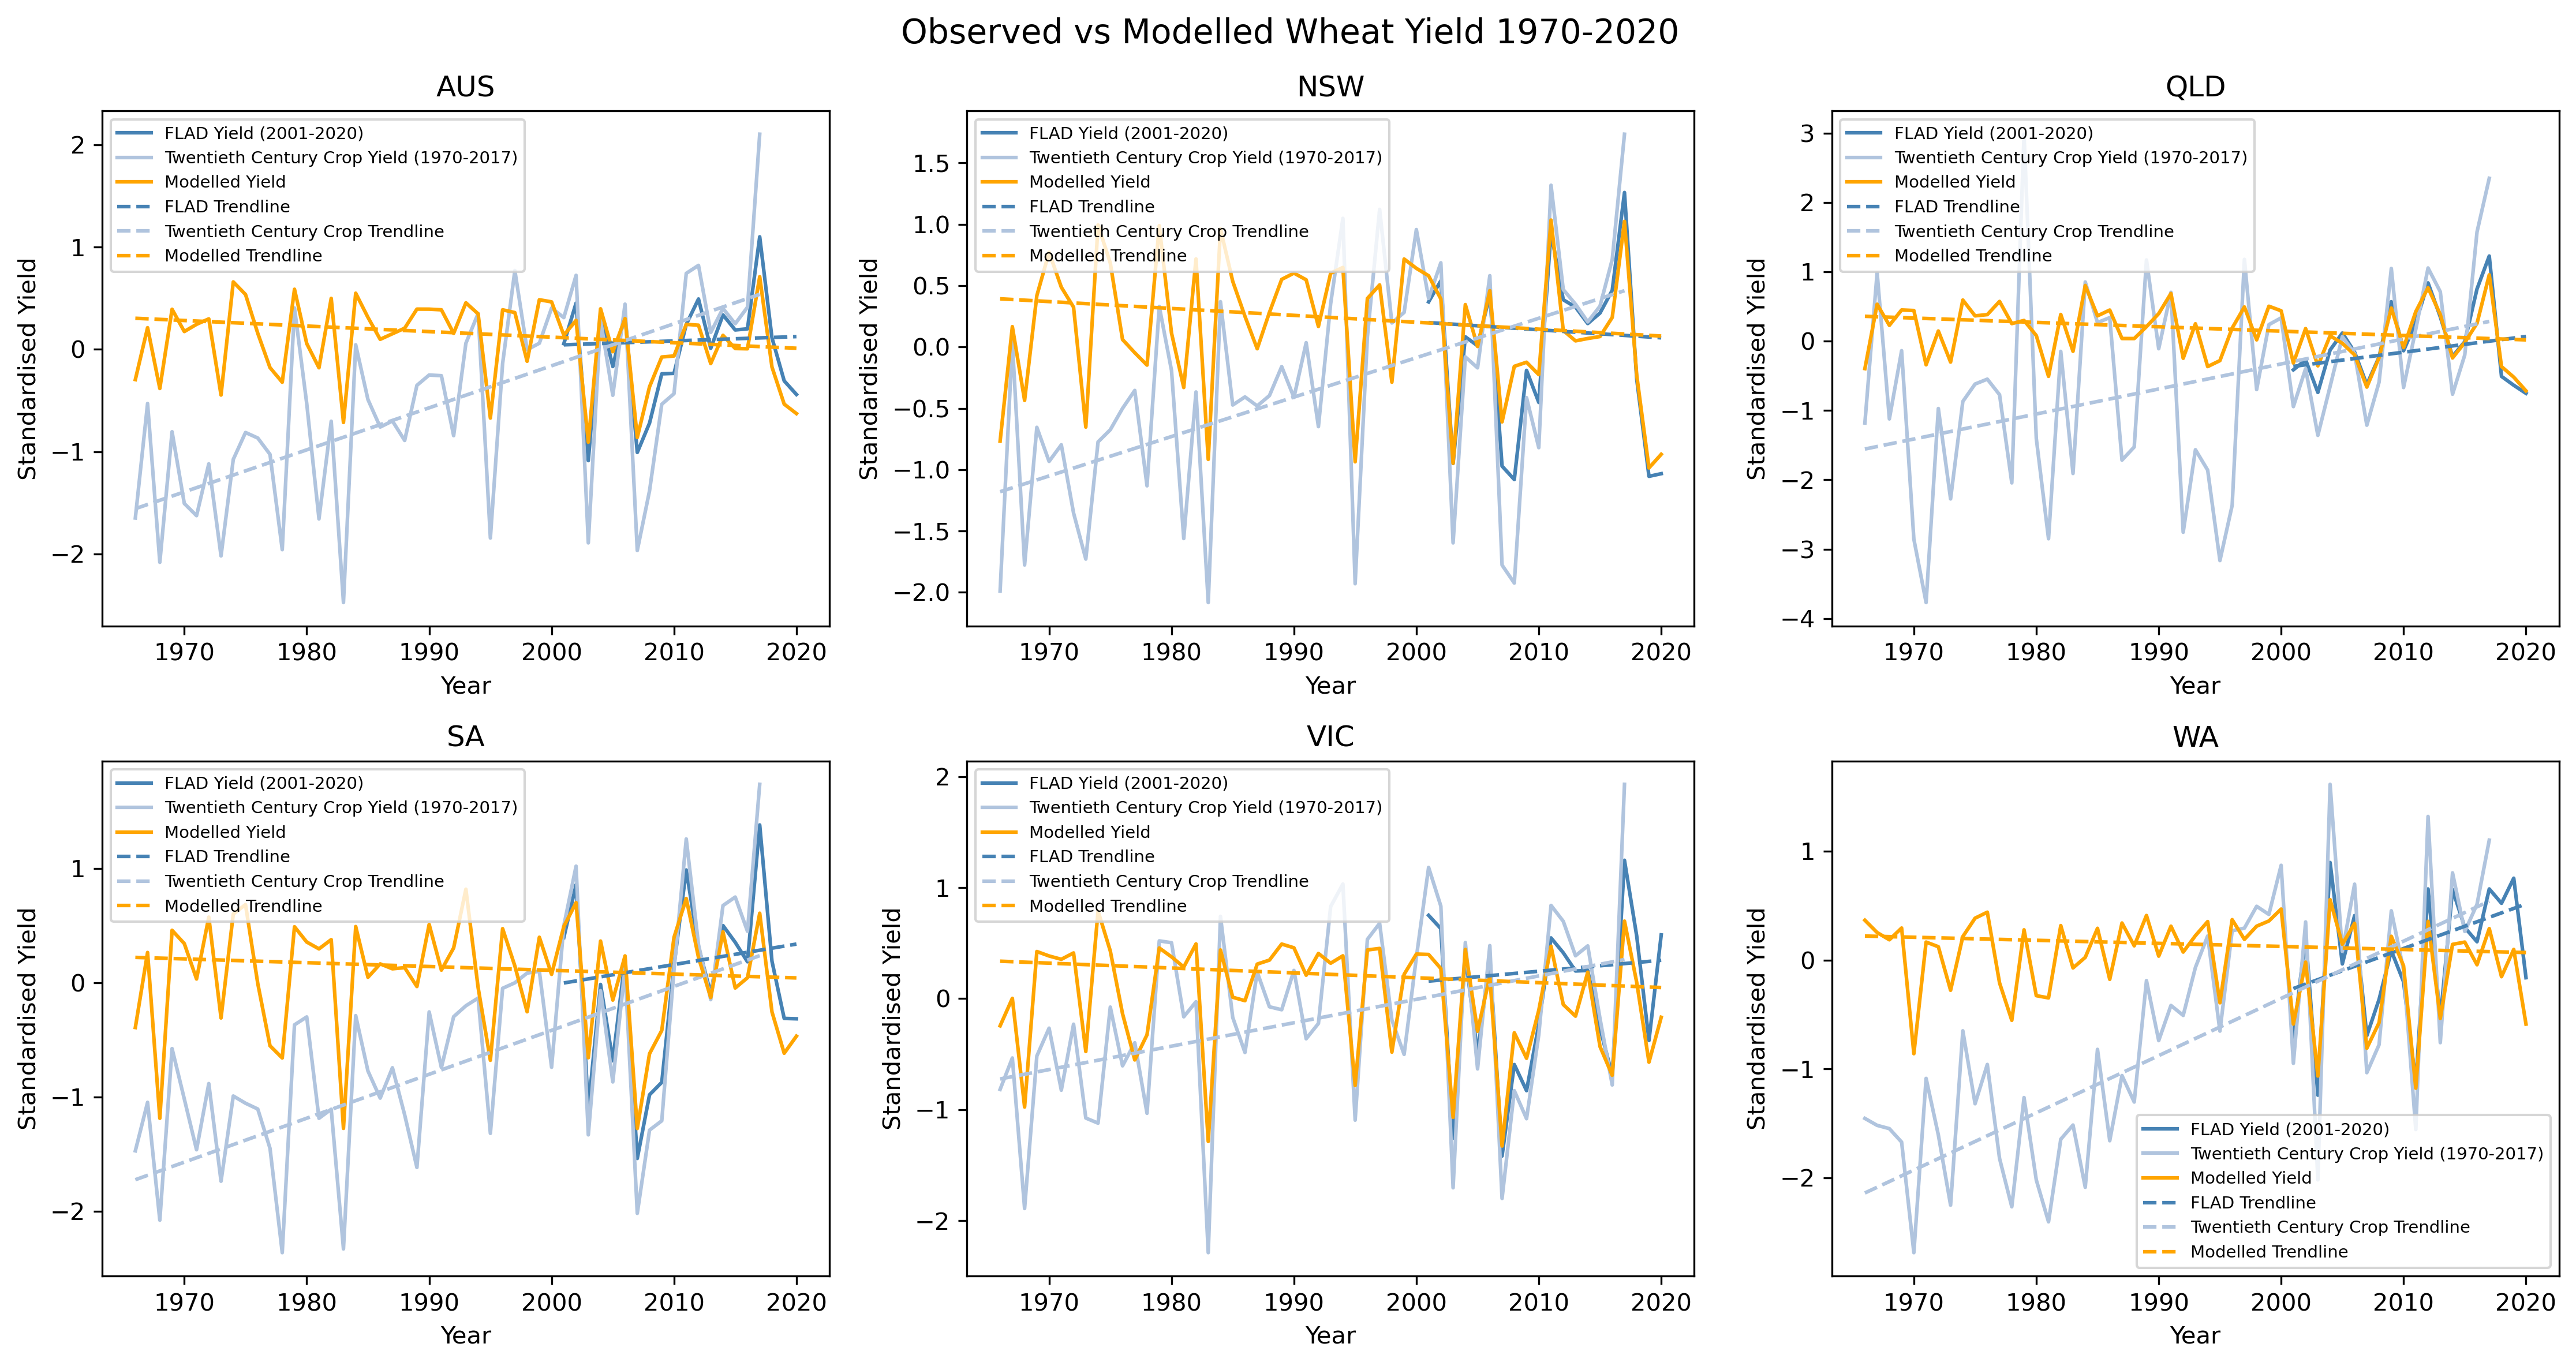

In [18]:
import pymannkendall as mk
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=300)
axes = axes.flatten()

for i, state in enumerate(states):
    ax = axes[i]
    ABS_state = ABS_subset[state]
    twent_cent_state = twent_cent_subset[state]
    model_state = model_yield_plot[state]

    mk_abs = mk.yue_wang_modification_test(ABS_state.values)
    mk_twent = mk.yue_wang_modification_test(twent_cent_state.values)
    mk_model = mk.yue_wang_modification_test(model_state.values)

    slope_abs = mk_abs.slope
    slope_twent = mk_twent.slope
    slope_model = mk_model.slope

    intercept_abs = mk_abs.intercept
    intercept_twent = mk_twent.intercept
    intercept_model = mk_model.intercept
    
    sig_abs = mk_abs.trend != "no trend"
    sig_twent = mk_twent.trend != "no trend"
    sig_model = mk_model.trend != "no trend"
    
    ABS_trendline = slope_abs * np.arange(len(ABS_subset['year'])) + intercept_abs
    twent_cent_trendline = slope_twent * np.arange(len(twent_cent_subset['year'])) + intercept_twent
    model_trendline = slope_model * np.arange(len(model_yield_plot['year'])) + intercept_model
    
    ax.plot(ABS_subset['year'], ABS_subset[state], 
            color='steelblue', label='FLAD Yield (2001-2020)')
    ax.plot(twent_cent_subset['year'], twent_cent_subset[state], 
            color='lightsteelblue', label='Twentieth Century Crop Yield (1970-2017)')
    ax.plot(model_yield_plot['year'], model_state, 
            color='orange', label='Modelled Yield')
    ax.plot(ABS_subset['year'], ABS_trendline,
            color='steelblue', linestyle='--', label='FLAD Trendline')
    ax.plot(twent_cent_subset['year'], twent_cent_trendline,
            color='lightsteelblue', linestyle='--', label='Twentieth Century Crop Trendline')
    ax.plot(model_yield_plot['year'], model_trendline,
            color='orange', linestyle='--', label='Modelled Trendline')
    join_years = [twent_cent_subset['year'].iloc[-1], ABS_subset['year'].iloc[0]]
    join_vals = [twent_cent_subset[state].iloc[-1], ABS_subset[state].iloc[0]]

    
    ax.set_title(state)
    ax.set_xlabel('Year')
    ax.set_ylabel('Standardised Yield')
    ax.legend(fontsize=7)


plt.suptitle('Observed vs Modelled Wheat Yield 1970-2020', fontsize=14)
plt.tight_layout()
plt.savefig('yield_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

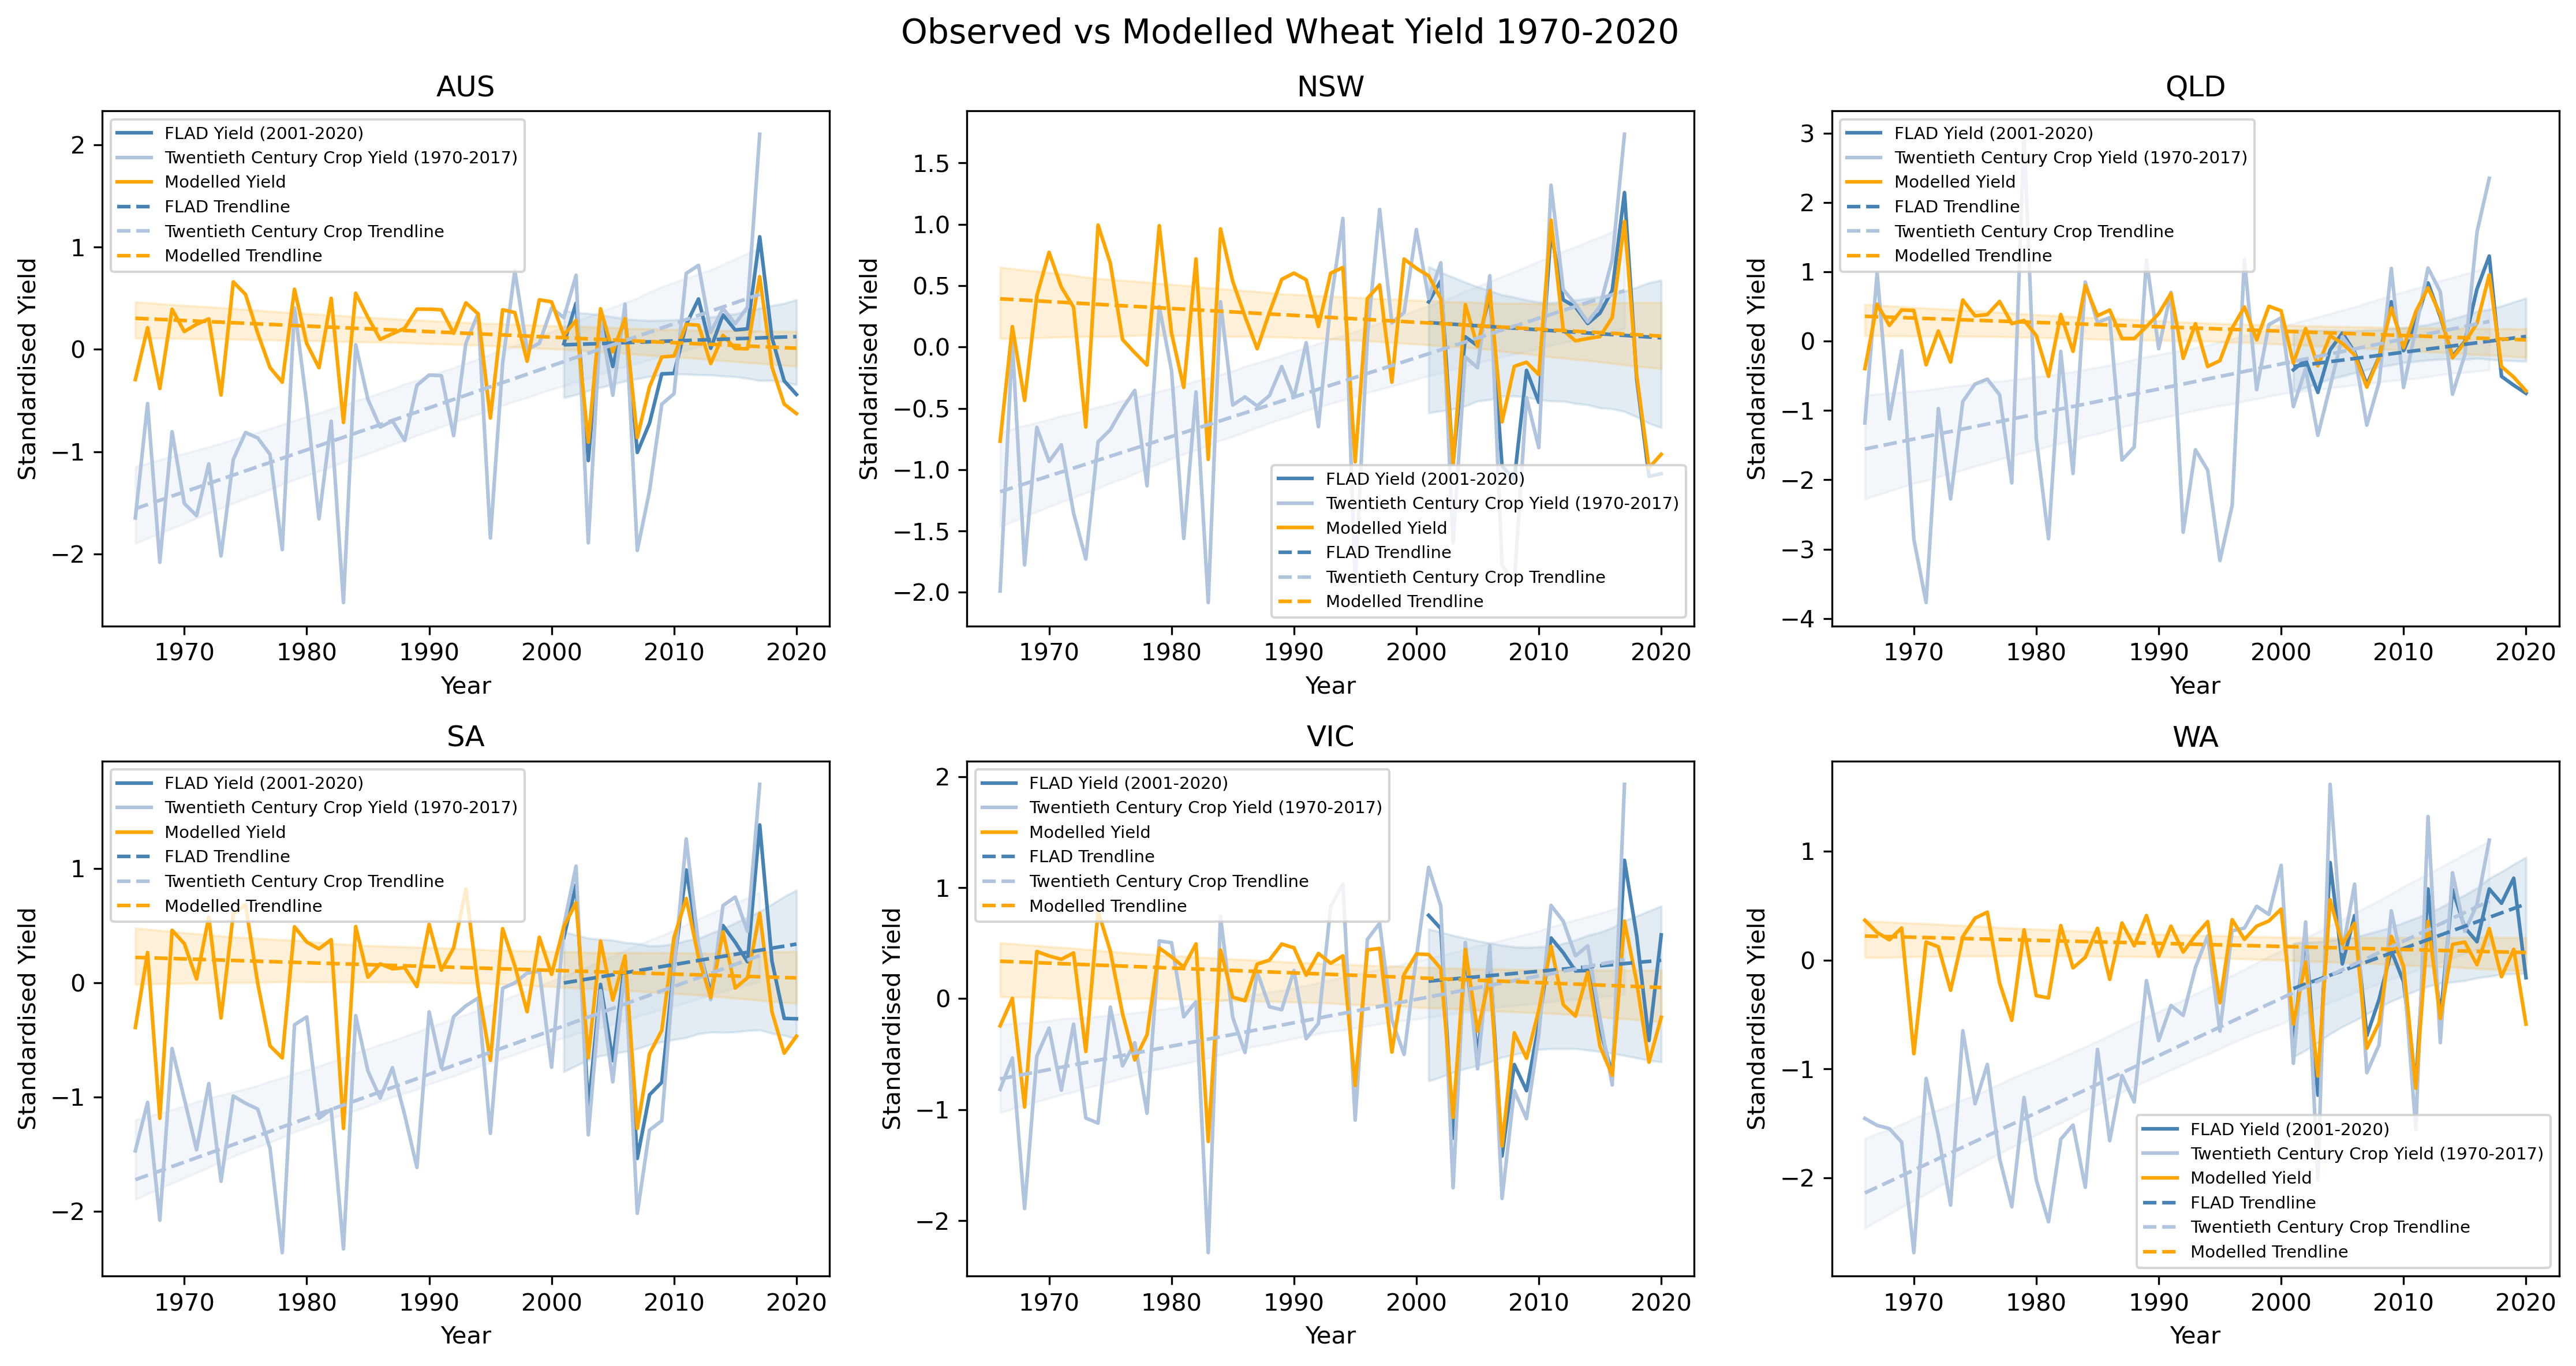

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

def bootstrap_slope_intercept(y, n_boot=1000, random_state=None):
    """Residual bootstrap of Yue-Wang Theil-Sen slope/intercept for a 1D array."""
    rng = np.random.default_rng(random_state)
    n = len(y)
    x = np.arange(n)

    base = mk.yue_wang_modification_test(y)
    slope0, intercept0 = base.slope, base.intercept
    fitted = slope0 * x + intercept0
    residuals = y - fitted

    boot_slopes = np.empty(n_boot)
    boot_intercepts = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_boot = fitted + residuals[idx]
        res = mk.yue_wang_modification_test(y_boot)
        boot_slopes[i] = res.slope
        boot_intercepts[i] = res.intercept

    return slope0, intercept0, base.trend, boot_slopes, boot_intercepts


def trend_band(x, slope0, intercept0, boot_slopes, boot_intercepts, ci=95):
    """Trendline + percentile uncertainty band evaluated over x."""
    trendline = slope0 * x + intercept0
    lo_pct, hi_pct = (100 - ci) / 2, 100 - (100 - ci) / 2
    boot_lines = boot_slopes[:, None] * x[None, :] + boot_intercepts[:, None]
    lower = np.percentile(boot_lines, lo_pct, axis=0)
    upper = np.percentile(boot_lines, hi_pct, axis=0)
    return trendline, lower, upper


n_boot = 1000
colors = {"abs": "steelblue", "twent": "lightsteelblue", "model": "orange"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=300)
axes = axes.flatten()

for i, state in enumerate(states):
    ax = axes[i]
    ABS_state = ABS_subset[state]
    twent_cent_state = twent_cent_subset[state]
    model_state = model_yield_plot[state]

    x_abs = np.arange(len(ABS_subset["year"]))
    x_twent = np.arange(len(twent_cent_subset["year"]))
    x_model = np.arange(len(model_yield_plot["year"]))

    slope_abs, intercept_abs, trend_abs, bs_abs, bi_abs = bootstrap_slope_intercept(
        ABS_state.values, n_boot=n_boot, random_state=42)
    slope_twent, intercept_twent, trend_twent, bs_twent, bi_twent = bootstrap_slope_intercept(
        twent_cent_state.values, n_boot=n_boot, random_state=42)
    slope_model, intercept_model, trend_model, bs_model, bi_model = bootstrap_slope_intercept(
        model_state.values, n_boot=n_boot, random_state=42)

    ABS_trendline, ABS_lower, ABS_upper = trend_band(x_abs, slope_abs, intercept_abs, bs_abs, bi_abs)
    twent_trendline, twent_lower, twent_upper = trend_band(x_twent, slope_twent, intercept_twent, bs_twent, bi_twent)
    model_trendline, model_lower, model_upper = trend_band(x_model, slope_model, intercept_model, bs_model, bi_model)

    ax.plot(ABS_subset["year"], ABS_state, color=colors["abs"], label="FLAD Yield (2001-2020)")
    ax.plot(twent_cent_subset["year"], twent_cent_state, color=colors["twent"], label="Twentieth Century Crop Yield (1970-2017)")
    ax.plot(model_yield_plot["year"], model_state, color=colors["model"], label="Modelled Yield")

    ax.plot(ABS_subset["year"], ABS_trendline, color=colors["abs"], linestyle="--", label="FLAD Trendline")
    ax.plot(twent_cent_subset["year"], twent_trendline, color=colors["twent"], linestyle="--", label="Twentieth Century Crop Trendline")
    ax.plot(model_yield_plot["year"], model_trendline, color=colors["model"], linestyle="--", label="Modelled Trendline")

    ax.fill_between(ABS_subset["year"], ABS_lower, ABS_upper, color=colors["abs"], alpha=0.15)
    ax.fill_between(twent_cent_subset["year"], twent_lower, twent_upper, color=colors["twent"], alpha=0.15)
    ax.fill_between(model_yield_plot["year"], model_lower, model_upper, color=colors["model"], alpha=0.15)

    ax.set_title(state)
    ax.set_xlabel("Year")
    ax.set_ylabel("Standardised Yield")
    ax.legend(fontsize=7)

for j in range(len(states), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Observed vs Modelled Wheat Yield 1970-2020", fontsize=14)
plt.tight_layout()
plt.show()

### Annual Timseries, Annual Trend

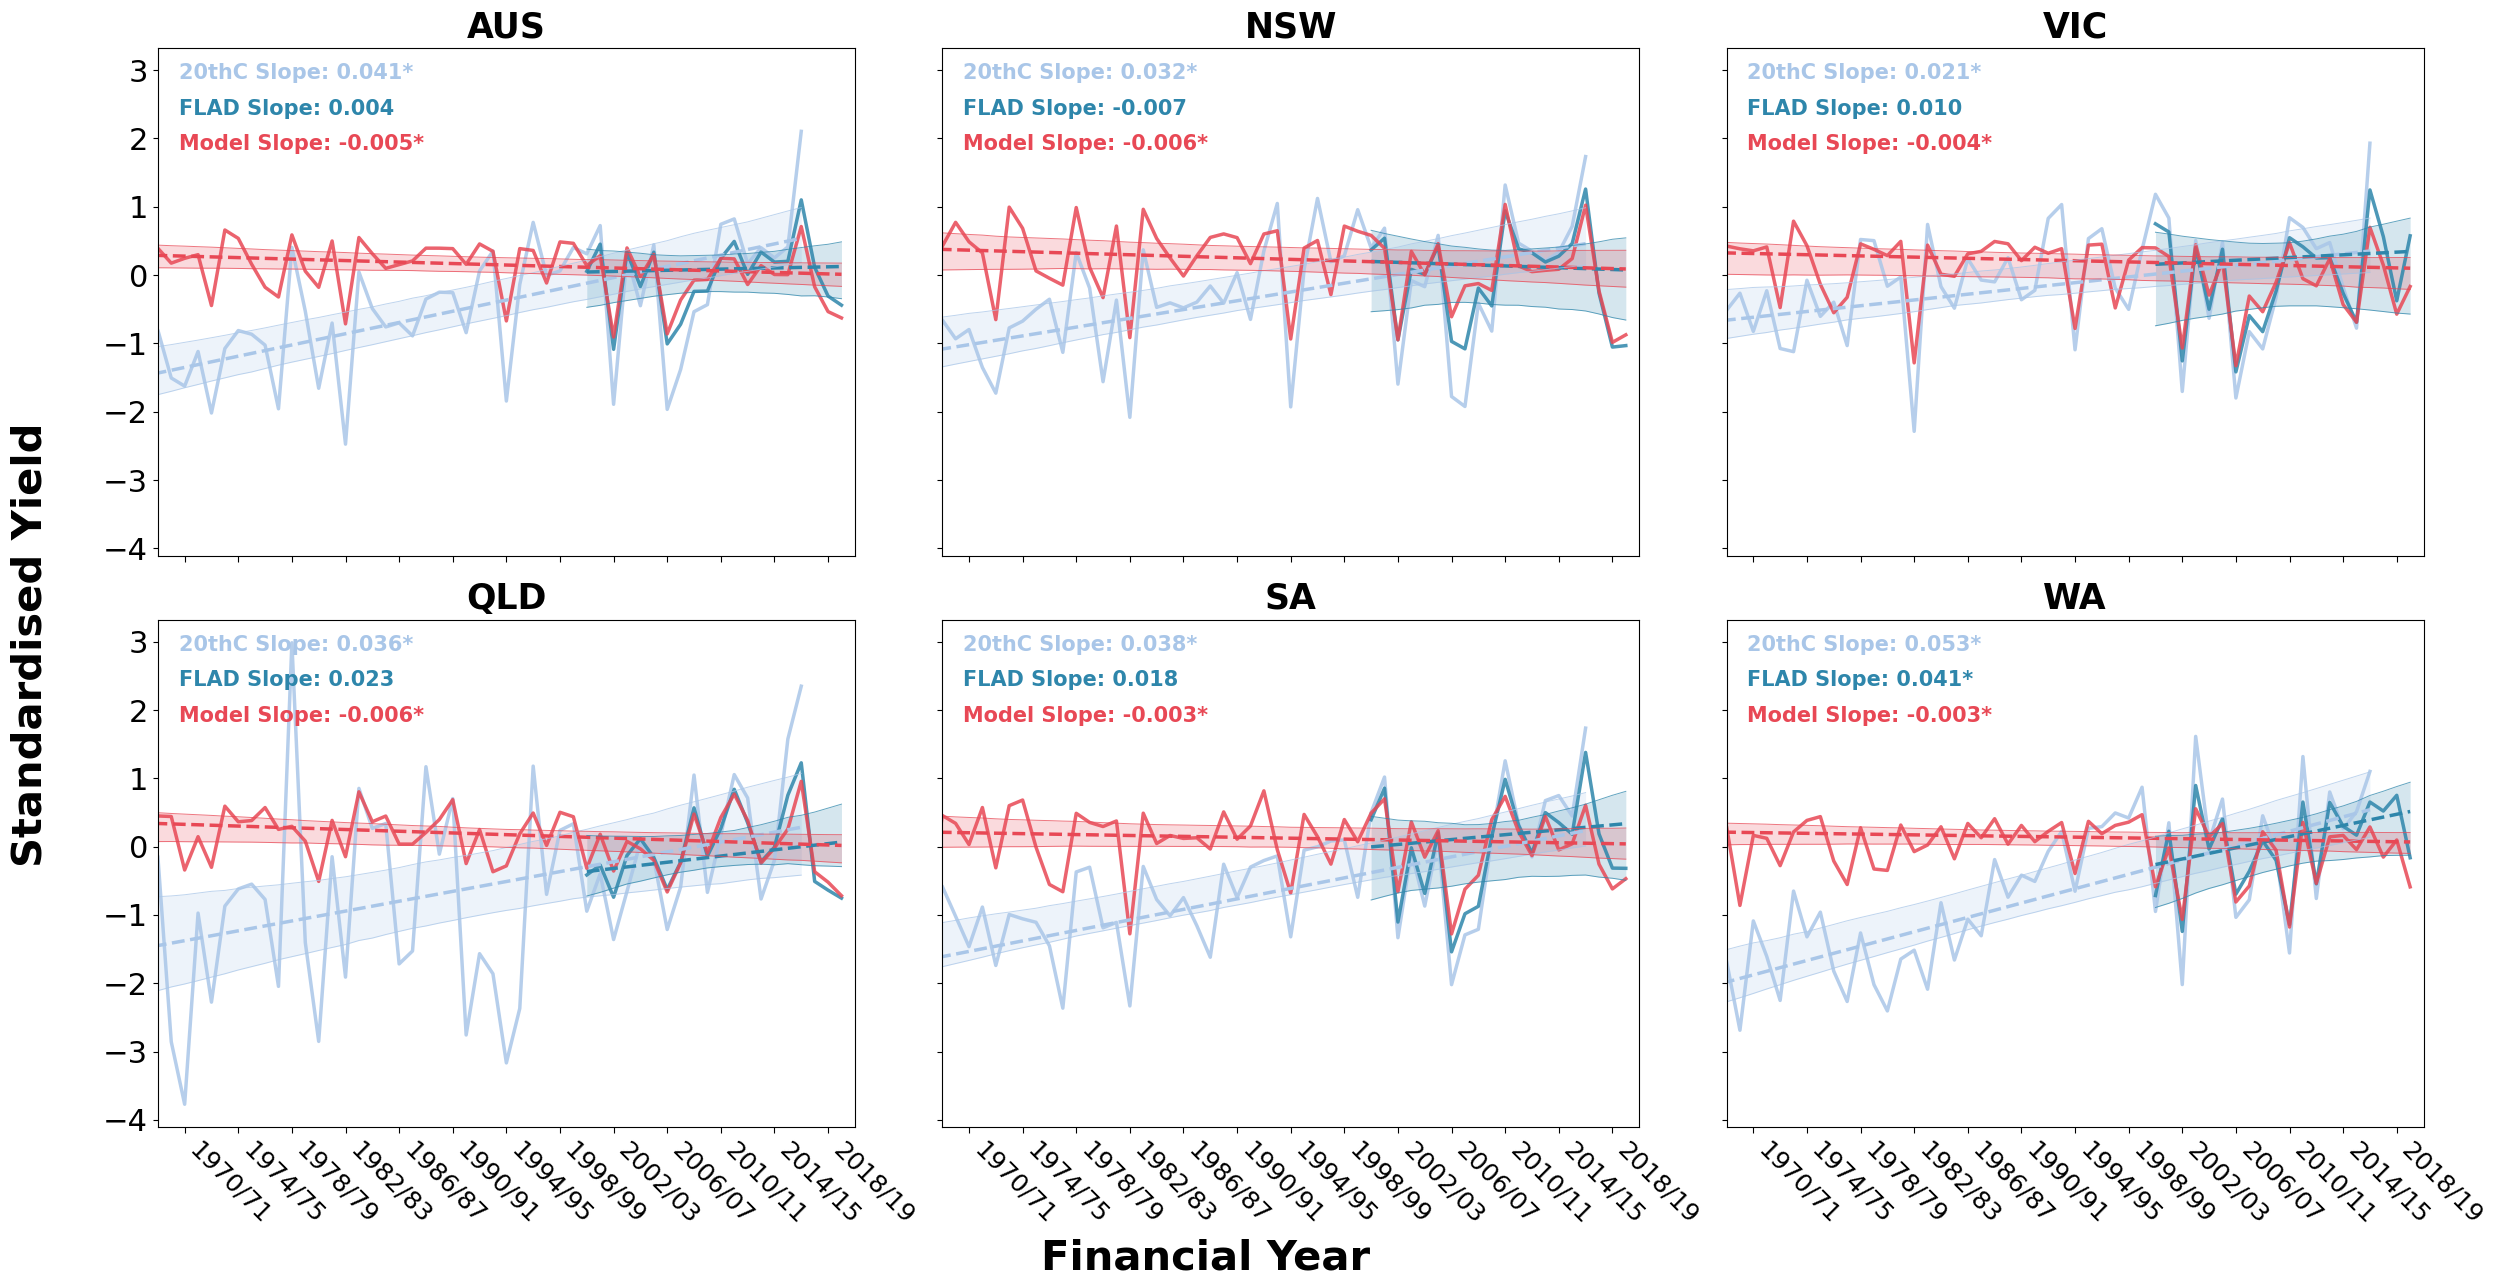

In [20]:
import pymannkendall as mk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Palette
col_twent = "#A9C6E8"   # light blue - twentieth century obs
col_abs   = "#2E86AB"   # blue - obs (FLAD/ABS)
col_model = "#E84855"   # reddish - modelled


def bootstrap_slope_intercept(y, n_boot=1000, random_state=None):
    """Residual bootstrap of Yue-Wang Theil-Sen slope/intercept for a 1D array."""
    rng = np.random.default_rng(random_state)
    n = len(y)
    x = np.arange(n)

    base = mk.yue_wang_modification_test(y)
    slope0, intercept0 = base.slope, base.intercept
    fitted = slope0 * x + intercept0
    residuals = y - fitted

    boot_slopes = np.empty(n_boot)
    boot_intercepts = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_boot = fitted + residuals[idx]
        res = mk.yue_wang_modification_test(y_boot)
        boot_slopes[i] = res.slope
        boot_intercepts[i] = res.intercept

    return slope0, intercept0, base.trend, boot_slopes, boot_intercepts


def bootstrap_band(x, slope0, intercept0, boot_slopes, boot_intercepts, ci=95):
    """
    Direct (non-pivoted) bootstrap uncertainty band: evaluate every
    bootstrapped (slope, intercept) line across x, then take percentiles
    at each x. Because slope and intercept are correlated across
    bootstrap draws, this band is not perfectly linear/fan-shaped -- it
    can flex slightly along x, unlike a band pivoted through one fixed point.
    """
    trendline = slope0 * x + intercept0
    lo_pct, hi_pct = (100 - ci) / 2, 100 - (100 - ci) / 2
    boot_lines = boot_slopes[:, None] * x[None, :] + boot_intercepts[:, None]
    lower = np.percentile(boot_lines, lo_pct, axis=0)
    upper = np.percentile(boot_lines, hi_pct, axis=0)
    return trendline, lower, upper

states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']

n_boot = 1000
full_years = np.arange(1971, 2021)

fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):
    abs_vals = ABS_subset[state].values
    twent_vals = twent_cent_subset[state].values
    model_vals = model_yield_plot[state].values

    twent_years = twent_cent_subset['year']
    abs_years = ABS_subset['year']
    model_years = model_yield_plot['year']

    tick_years = full_years[::4]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

    slope_twent, intercept_twent, trend_twent, bs_twent, bi_twent = bootstrap_slope_intercept(
        twent_vals, n_boot=n_boot, random_state=42)
    slope_abs, intercept_abs, trend_abs, bs_abs, bi_abs = bootstrap_slope_intercept(
        abs_vals, n_boot=n_boot, random_state=42)
    slope_model, intercept_model, trend_model, bs_model, bi_model = bootstrap_slope_intercept(
        model_vals, n_boot=n_boot, random_state=42)

    sig_twent = trend_twent != "no trend"
    sig_abs = trend_abs != "no trend"
    sig_model = trend_model != "no trend"

    x_twent = np.arange(len(twent_years))
    x_abs = np.arange(len(abs_years))
    x_model = np.arange(len(model_years))

    twent_trend, twent_lower, twent_upper = bootstrap_band(x_twent, slope_twent, intercept_twent, bs_twent, bi_twent)
    abs_trend, abs_lower, abs_upper = bootstrap_band(x_abs, slope_abs, intercept_abs, bs_abs, bi_abs)
    model_trend, model_lower, model_upper = bootstrap_band(x_model, slope_model, intercept_model, bs_model, bi_model)

    # observed series
    ax.plot(twent_years, twent_vals, color=col_twent, linewidth=2.5, alpha=0.85)
    ax.plot(abs_years, abs_vals, color=col_abs, linewidth=2.5, alpha=0.85)
    ax.plot(model_years, model_vals, color=col_model, linewidth=2.5, alpha=0.85)

    # trendlines
    ax.plot(twent_years, twent_trend, color=col_twent, linewidth=2.5, linestyle="--")
    ax.plot(abs_years, abs_trend, color=col_abs, linewidth=2.5, linestyle="--")
    ax.plot(model_years, model_trend, color=col_model, linewidth=2.5, linestyle="--")

    # bootstrap uncertainty bands (curved, direct percentile of bootstrapped lines)
    ax.fill_between(twent_years, twent_lower, twent_upper, color=col_twent, alpha=0.2, linewidth=0)
    ax.fill_between(abs_years, abs_lower, abs_upper, color=col_abs, alpha=0.2, linewidth=0)
    ax.fill_between(model_years, model_lower, model_upper, color=col_model, alpha=0.2, linewidth=0)

    # thin border lines on the bands
    ax.plot(twent_years, twent_lower, color=col_twent, linewidth=0.7, alpha=0.75)
    ax.plot(twent_years, twent_upper, color=col_twent, linewidth=0.7, alpha=0.75)
    ax.plot(abs_years, abs_lower, color=col_abs, linewidth=0.7, alpha=0.75)
    ax.plot(abs_years, abs_upper, color=col_abs, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_lower, color=col_model, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_upper, color=col_model, linewidth=0.7, alpha=0.75)

    sig_marker_twent = "*" if sig_twent else ""
    sig_marker_abs = "*" if sig_abs else ""
    sig_marker_model = "*" if sig_model else ""
    text_twent = f"20thC Slope: {slope_twent:.3f}{sig_marker_twent}"
    text_abs = f"FLAD Slope: {slope_abs:.3f}{sig_marker_abs}"
    text_model = f"Model Slope: {slope_model:.3f}{sig_marker_model}"

    ax.text(0.03, 0.97, text_twent, color=col_twent,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.90, text_abs, color=col_abs,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.83, text_model, color=col_model,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")

    ax.set_title(state, fontsize=25, fontweight="bold", pad=8)
    ax.set_xlim(1969, 2021)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=18)
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', which='both', length=4)

fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=30, fontweight="bold")
fig.text(0.04, 0.5, "Standardised Yield",
         va='center', rotation='vertical', fontsize=30, fontweight="bold")

plt.tight_layout(rect=[0.07, 0.04, 1, 1])
# plt.savefig("/home/claude/publication_style_3series_bootstrap.png", dpi=150, bbox_inches="tight")


### Rolling timeseries, rolling trend (bootstrapped after rolling)

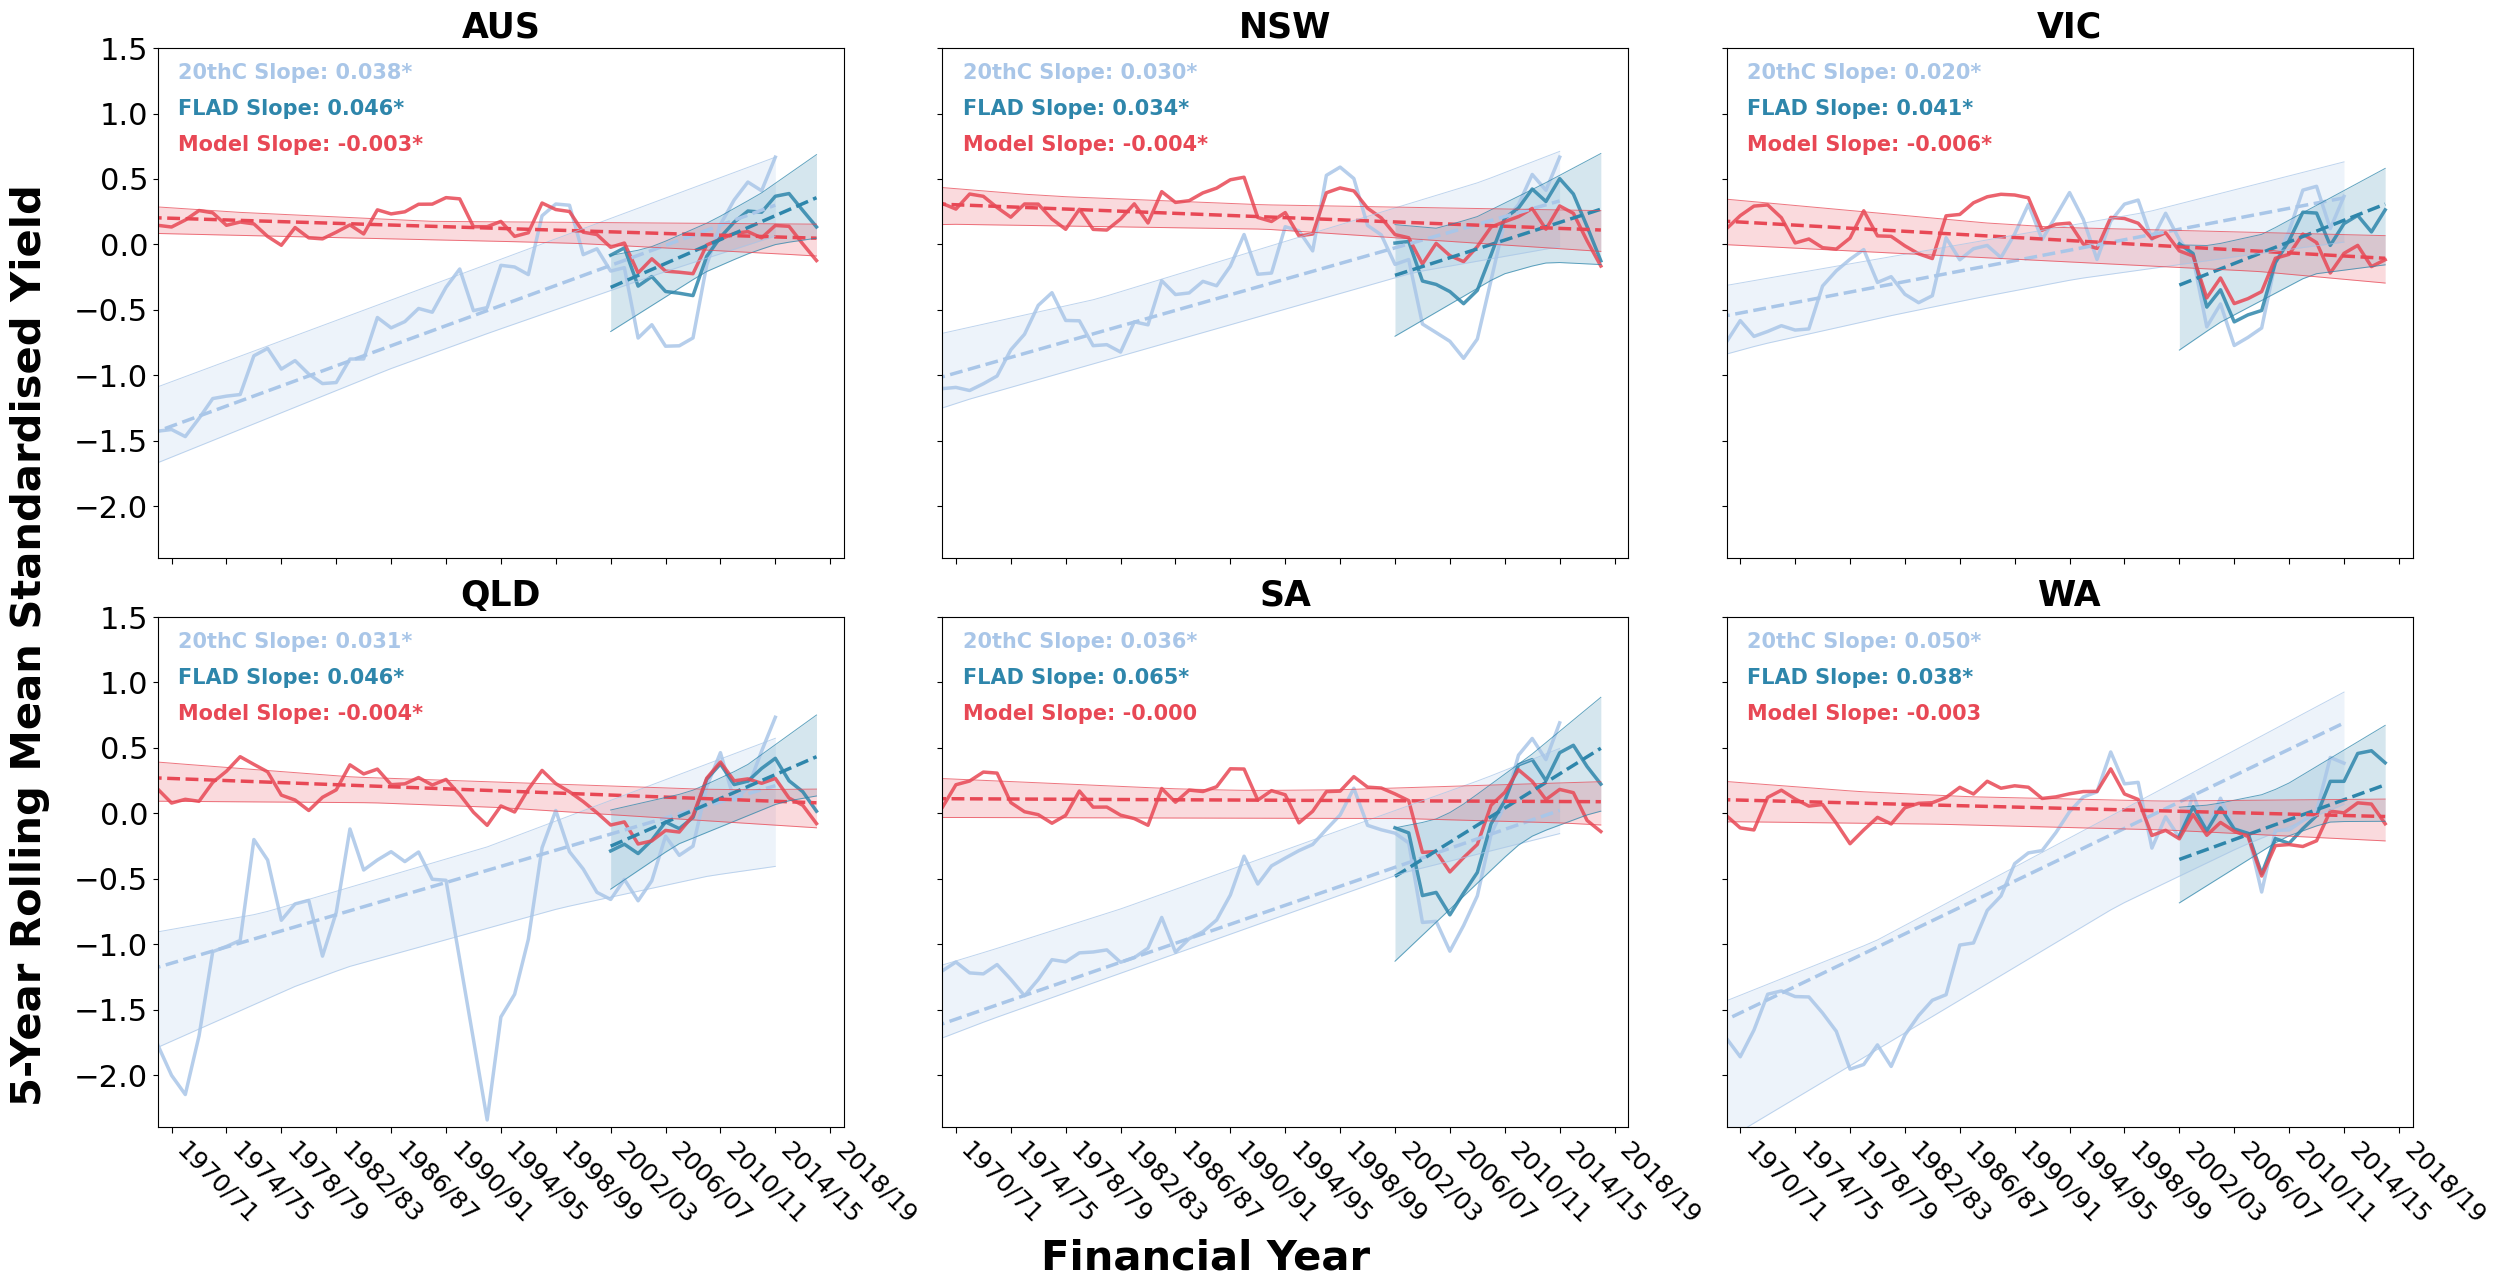

In [21]:
ROLL_WINDOW = 5
# model_yield_plot = model_yield_sorted[model_yield_sorted['year'] >= 1965]
# model_yield_plot = model_yield_plot[model_yield_plot['year'] <= 2020]

# twent_cent_subset = twent_cent_df[(twent_cent_df['year'] >= 1965)]

def rolling_mean_series(years, values, window=ROLL_WINDOW):
    """
    Centered rolling mean, dropping the NaN edges the rolling window
    can't fill. Returns the trimmed years and rolling-mean values,
    aligned 1:1.
    """
    s = pd.Series(values, index=years)
    roll = s.rolling(window=window, center=True, min_periods=window).mean()
    roll = roll.dropna()
    return roll.index.to_numpy(), roll.to_numpy()


states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']

n_boot = 1000
full_years = np.arange(1971, 2021)

fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):
    abs_vals = ABS_subset[state].values
    twent_vals = twent_cent_subset[state].values
    model_vals = model_yield_plot[state].values

    twent_years = twent_cent_subset['year'].values
    abs_years = ABS_subset['year'].values
    model_years = model_yield_plot['year'].values

    # 5-year centered rolling mean, trimmed to valid (non-NaN) years
    twent_years_r, twent_vals_r = rolling_mean_series(twent_years, twent_vals)
    abs_years_r, abs_vals_r = rolling_mean_series(abs_years, abs_vals)
    model_years_r, model_vals_r = rolling_mean_series(model_years, model_vals)

    tick_years = full_years[::4]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

    slope_twent, intercept_twent, trend_twent, bs_twent, bi_twent = bootstrap_slope_intercept(
        twent_vals_r, n_boot=n_boot, random_state=42)
    slope_abs, intercept_abs, trend_abs, bs_abs, bi_abs = bootstrap_slope_intercept(
        abs_vals_r, n_boot=n_boot, random_state=42)
    slope_model, intercept_model, trend_model, bs_model, bi_model = bootstrap_slope_intercept(
        model_vals_r, n_boot=n_boot, random_state=42)

    sig_twent = trend_twent != "no trend"
    sig_abs = trend_abs != "no trend"
    sig_model = trend_model != "no trend"

    x_twent = np.arange(len(twent_years_r))
    x_abs = np.arange(len(abs_years_r))
    x_model = np.arange(len(model_years_r))

    twent_trend, twent_lower, twent_upper = bootstrap_band(x_twent, slope_twent, intercept_twent, bs_twent, bi_twent, ci=100)
    abs_trend, abs_lower, abs_upper = bootstrap_band(x_abs, slope_abs, intercept_abs, bs_abs, bi_abs, ci=100)
    model_trend, model_lower, model_upper = bootstrap_band(x_model, slope_model, intercept_model, bs_model, bi_model, ci=100)

    # rolling-mean series
    ax.plot(twent_years_r, twent_vals_r, color=col_twent, linewidth=2.5, alpha=0.85)
    ax.plot(abs_years_r, abs_vals_r, color=col_abs, linewidth=2.5, alpha=0.85)
    ax.plot(model_years_r, model_vals_r, color=col_model, linewidth=2.5, alpha=0.85)

    # trendlines (fit on rolling-mean values)
    ax.plot(twent_years_r, twent_trend, color=col_twent, linewidth=2.5, linestyle="--")
    ax.plot(abs_years_r, abs_trend, color=col_abs, linewidth=2.5, linestyle="--")
    ax.plot(model_years_r, model_trend, color=col_model, linewidth=2.5, linestyle="--")

    # bootstrap uncertainty bands (curved, direct percentile of bootstrapped lines)
    ax.fill_between(twent_years_r, twent_lower, twent_upper, color=col_twent, alpha=0.2, linewidth=0)
    ax.fill_between(abs_years_r, abs_lower, abs_upper, color=col_abs, alpha=0.2, linewidth=0)
    ax.fill_between(model_years_r, model_lower, model_upper, color=col_model, alpha=0.2, linewidth=0)

    # thin border lines on the bands
    ax.plot(twent_years_r, twent_lower, color=col_twent, linewidth=0.7, alpha=0.75)
    ax.plot(twent_years_r, twent_upper, color=col_twent, linewidth=0.7, alpha=0.75)
    ax.plot(abs_years_r, abs_lower, color=col_abs, linewidth=0.7, alpha=0.75)
    ax.plot(abs_years_r, abs_upper, color=col_abs, linewidth=0.7, alpha=0.75)
    ax.plot(model_years_r, model_lower, color=col_model, linewidth=0.7, alpha=0.75)
    ax.plot(model_years_r, model_upper, color=col_model, linewidth=0.7, alpha=0.75)

    sig_marker_twent = "*" if sig_twent else ""
    sig_marker_abs = "*" if sig_abs else ""
    sig_marker_model = "*" if sig_model else ""
    text_twent = f"20thC Slope: {slope_twent:.3f}{sig_marker_twent}"
    text_abs = f"FLAD Slope: {slope_abs:.3f}{sig_marker_abs}"
    text_model = f"Model Slope: {slope_model:.3f}{sig_marker_model}"

    ax.text(0.03, 0.97, text_twent, color=col_twent,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.90, text_abs, color=col_abs,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.83, text_model, color=col_model,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")

    ax.set_title(state, fontsize=25, fontweight="bold", pad=8)
    ax.set_xlim(1970, 2020)
    ax.set_ylim(-2.4, 1.5)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=18)
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', which='both', length=4)

fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=30, fontweight="bold")
fig.text(0.04, 0.5, f"{ROLL_WINDOW}-Year Rolling Mean Standardised Yield",
         va='center', rotation='vertical', fontsize=30, fontweight="bold")

plt.tight_layout(rect=[0.07, 0.04, 1, 1])
plt.savefig("yield_timeseries_rolling.png", dpi=300, bbox_inches="tight")
plt.show()

### Rolling timeseries, annual trend

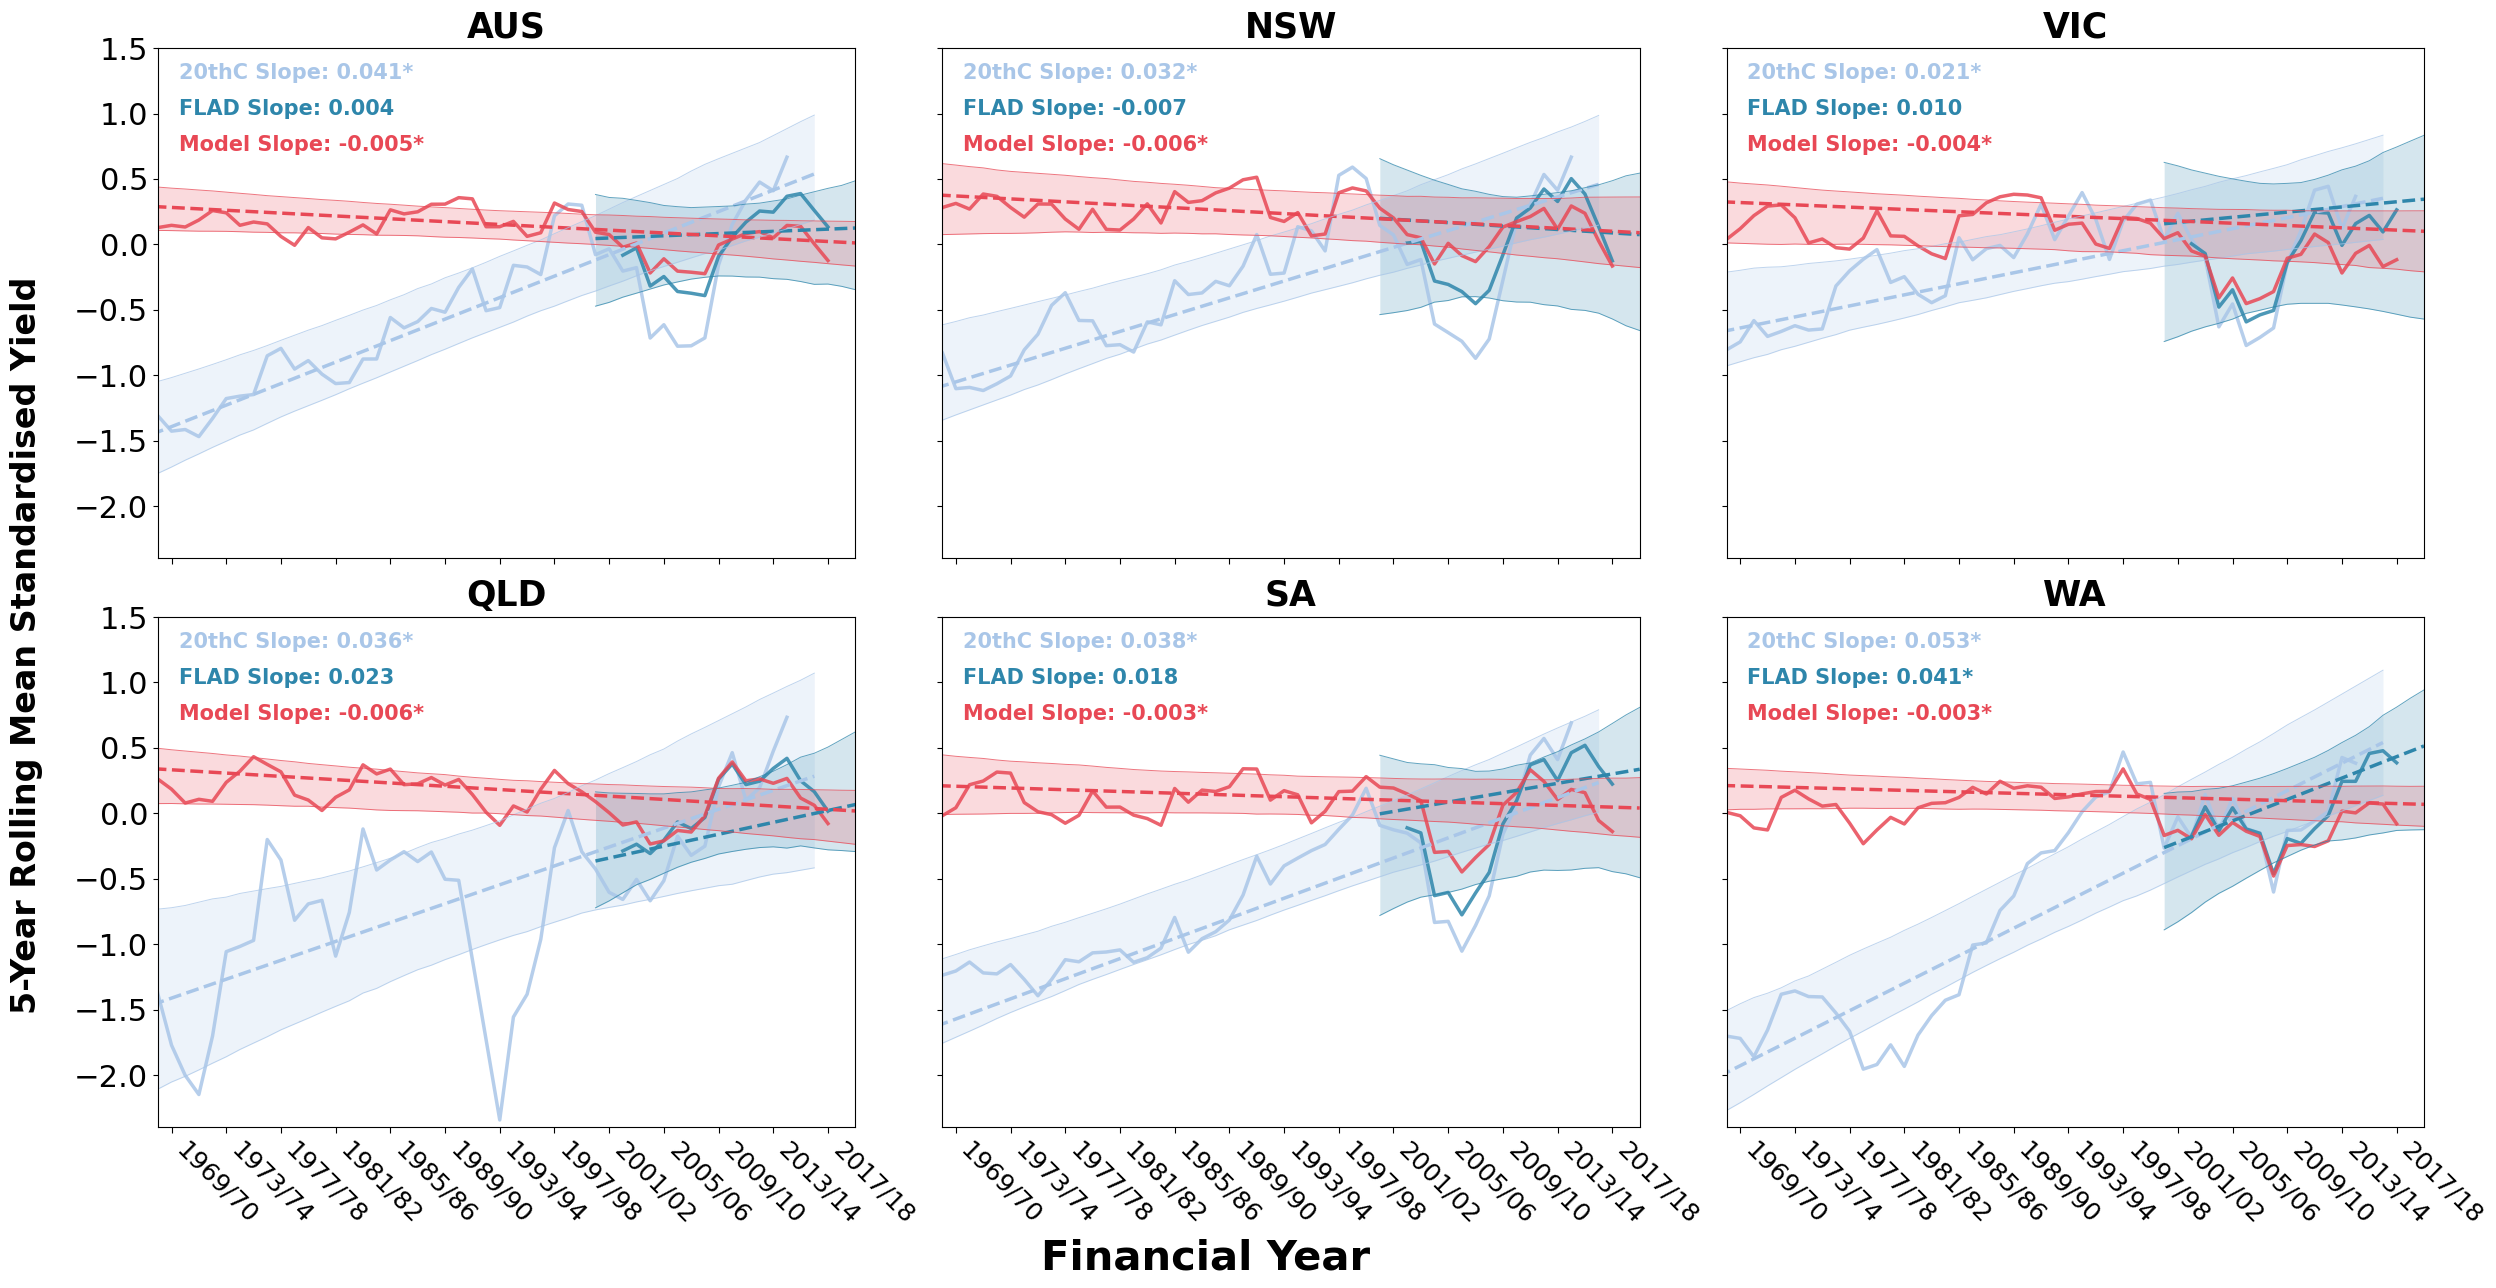

In [22]:
ROLL_WINDOW = 5

def rolling_mean_series(years, values, window=ROLL_WINDOW):
    """
    Centered rolling mean, dropping the NaN edges the rolling window
    can't fill. Used only for display -- NOT for trend fitting.
    """
    s = pd.Series(values, index=years)
    roll = s.rolling(window=window, center=True, min_periods=window).mean()
    roll = roll.dropna()
    return roll.index.to_numpy(), roll.to_numpy()


states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']

n_boot = 1000
full_years = np.arange(1970, 2020)

fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):
    abs_vals = ABS_subset[state].values
    twent_vals = twent_cent_subset[state].values
    model_vals = model_yield_plot[state].values

    twent_years = twent_cent_subset['year'].values
    abs_years = ABS_subset['year'].values
    model_years = model_yield_plot['year'].values

    # 5-year rolling mean -- for the DISPLAYED observed line only
    twent_years_r, twent_vals_r = rolling_mean_series(twent_years, twent_vals)
    abs_years_r, abs_vals_r = rolling_mean_series(abs_years, abs_vals)
    model_years_r, model_vals_r = rolling_mean_series(model_years, model_vals)

    tick_years = full_years[::4]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

    # trend + bootstrap fit on the RAW annual data (not the rolling mean)
    slope_twent, intercept_twent, trend_twent, bs_twent, bi_twent = bootstrap_slope_intercept(
        twent_vals, n_boot=n_boot, random_state=42)
    slope_abs, intercept_abs, trend_abs, bs_abs, bi_abs = bootstrap_slope_intercept(
        abs_vals, n_boot=n_boot, random_state=42)
    slope_model, intercept_model, trend_model, bs_model, bi_model = bootstrap_slope_intercept(
        model_vals, n_boot=n_boot, random_state=42)

    sig_twent = trend_twent != "no trend"
    sig_abs = trend_abs != "no trend"
    sig_model = trend_model != "no trend"

    x_twent = np.arange(len(twent_years))
    x_abs = np.arange(len(abs_years))
    x_model = np.arange(len(model_years))

    twent_trend, twent_lower, twent_upper = bootstrap_band(x_twent, slope_twent, intercept_twent, bs_twent, bi_twent)
    abs_trend, abs_lower, abs_upper = bootstrap_band(x_abs, slope_abs, intercept_abs, bs_abs, bi_abs)
    model_trend, model_lower, model_upper = bootstrap_band(x_model, slope_model, intercept_model, bs_model, bi_model)

    # observed series -- rolling mean, smoothed for display
    ax.plot(twent_years_r, twent_vals_r, color=col_twent, linewidth=2.5, alpha=0.85)
    ax.plot(abs_years_r, abs_vals_r, color=col_abs, linewidth=2.5, alpha=0.85)
    ax.plot(model_years_r, model_vals_r, color=col_model, linewidth=2.5, alpha=0.85)

    # trendlines -- fit on raw annual years, plotted over the full raw year range
    ax.plot(twent_years, twent_trend, color=col_twent, linewidth=2.5, linestyle="--")
    ax.plot(abs_years, abs_trend, color=col_abs, linewidth=2.5, linestyle="--")
    ax.plot(model_years, model_trend, color=col_model, linewidth=2.5, linestyle="--")

    # bootstrap uncertainty bands -- also over raw annual years
    ax.fill_between(twent_years, twent_lower, twent_upper, color=col_twent, alpha=0.2, linewidth=0)
    ax.fill_between(abs_years, abs_lower, abs_upper, color=col_abs, alpha=0.2, linewidth=0)
    ax.fill_between(model_years, model_lower, model_upper, color=col_model, alpha=0.2, linewidth=0)

    # thin border lines on the bands
    ax.plot(twent_years, twent_lower, color=col_twent, linewidth=0.7, alpha=0.75)
    ax.plot(twent_years, twent_upper, color=col_twent, linewidth=0.7, alpha=0.75)
    ax.plot(abs_years, abs_lower, color=col_abs, linewidth=0.7, alpha=0.75)
    ax.plot(abs_years, abs_upper, color=col_abs, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_lower, color=col_model, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_upper, color=col_model, linewidth=0.7, alpha=0.75)

    sig_marker_twent = "*" if sig_twent else ""
    sig_marker_abs = "*" if sig_abs else ""
    sig_marker_model = "*" if sig_model else ""
    text_twent = f"20thC Slope: {slope_twent:.3f}{sig_marker_twent}"
    text_abs = f"FLAD Slope: {slope_abs:.3f}{sig_marker_abs}"
    text_model = f"Model Slope: {slope_model:.3f}{sig_marker_model}"

    ax.text(0.03, 0.97, text_twent, color=col_twent,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.90, text_abs, color=col_abs,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.83, text_model, color=col_model,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")

    ax.set_title(state, fontsize=25, fontweight="bold", pad=8)
    ax.set_xlim(1969, 2020)
    ax.set_ylim(-2.4, 1.5)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=18)
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', which='both', length=4)

fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=30, fontweight="bold")
fig.text(0.04, 0.5, f"{ROLL_WINDOW}-Year Rolling Mean Standardised Yield",
         va='center', rotation='vertical', fontsize=24, fontweight="bold")

plt.tight_layout(rect=[0.07, 0.04, 1, 1])
plt.savefig("yield_timeseries_rolling.png", dpi=300, bbox_inches="tight")
plt.show()

### Rolling timeseries, rolling trend (boostrapped, then rolled)

In [23]:
def bootstrap_rolling_trend(years, values, window=5, n_boot=1000, random_state=None, roll_center=False):
    """
    1. Fit Theil-Sen (Yue-Wang) trend on the RAW annual data.
    2. Compute residuals from that raw fit.
    3. Resample the raw residuals (roughly independent, unlike residuals
       of an already-smoothed series) and add back to the raw fit
       -> a bootstrapped raw annual replicate.
    4. Apply the SAME 5-year rolling mean to that replicate.
    5. Fit Theil-Sen (Yue-Wang) trend on the smoothed replicate.
    Repeat n_boot times.
    """
    rng = np.random.default_rng(random_state)
    years = np.asarray(years); values = np.asarray(values)
    n = len(values)
    x_raw = np.arange(n)

    base_raw = mk.yue_wang_modification_test(values)
    slope_raw, intercept_raw = base_raw.slope, base_raw.intercept
    fitted_raw = slope_raw * x_raw + intercept_raw
    residuals_raw = values - fitted_raw

    obs_series = pd.Series(values, index=years)
    obs_roll = obs_series.rolling(window=window, center=roll_center, min_periods=window).mean().dropna()
    roll_years, roll_vals = obs_roll.index.to_numpy(), obs_roll.to_numpy()

    base_roll = mk.yue_wang_modification_test(roll_vals)
    slope0, intercept0 = base_roll.slope, base_roll.intercept

    boot_slopes, boot_intercepts = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_boot_raw = fitted_raw + residuals_raw[idx]

        s_boot = pd.Series(y_boot_raw, index=years)
        roll_boot = s_boot.rolling(window=window, center=roll_center, min_periods=window).mean().dropna()
        if len(roll_boot) < 3:
            continue

        res_boot = mk.yue_wang_modification_test(roll_boot.to_numpy())
        boot_slopes.append(res_boot.slope)
        boot_intercepts.append(res_boot.intercept)
    return roll_years, roll_vals, slope0, intercept0, np.array(boot_slopes), np.array(boot_intercepts)

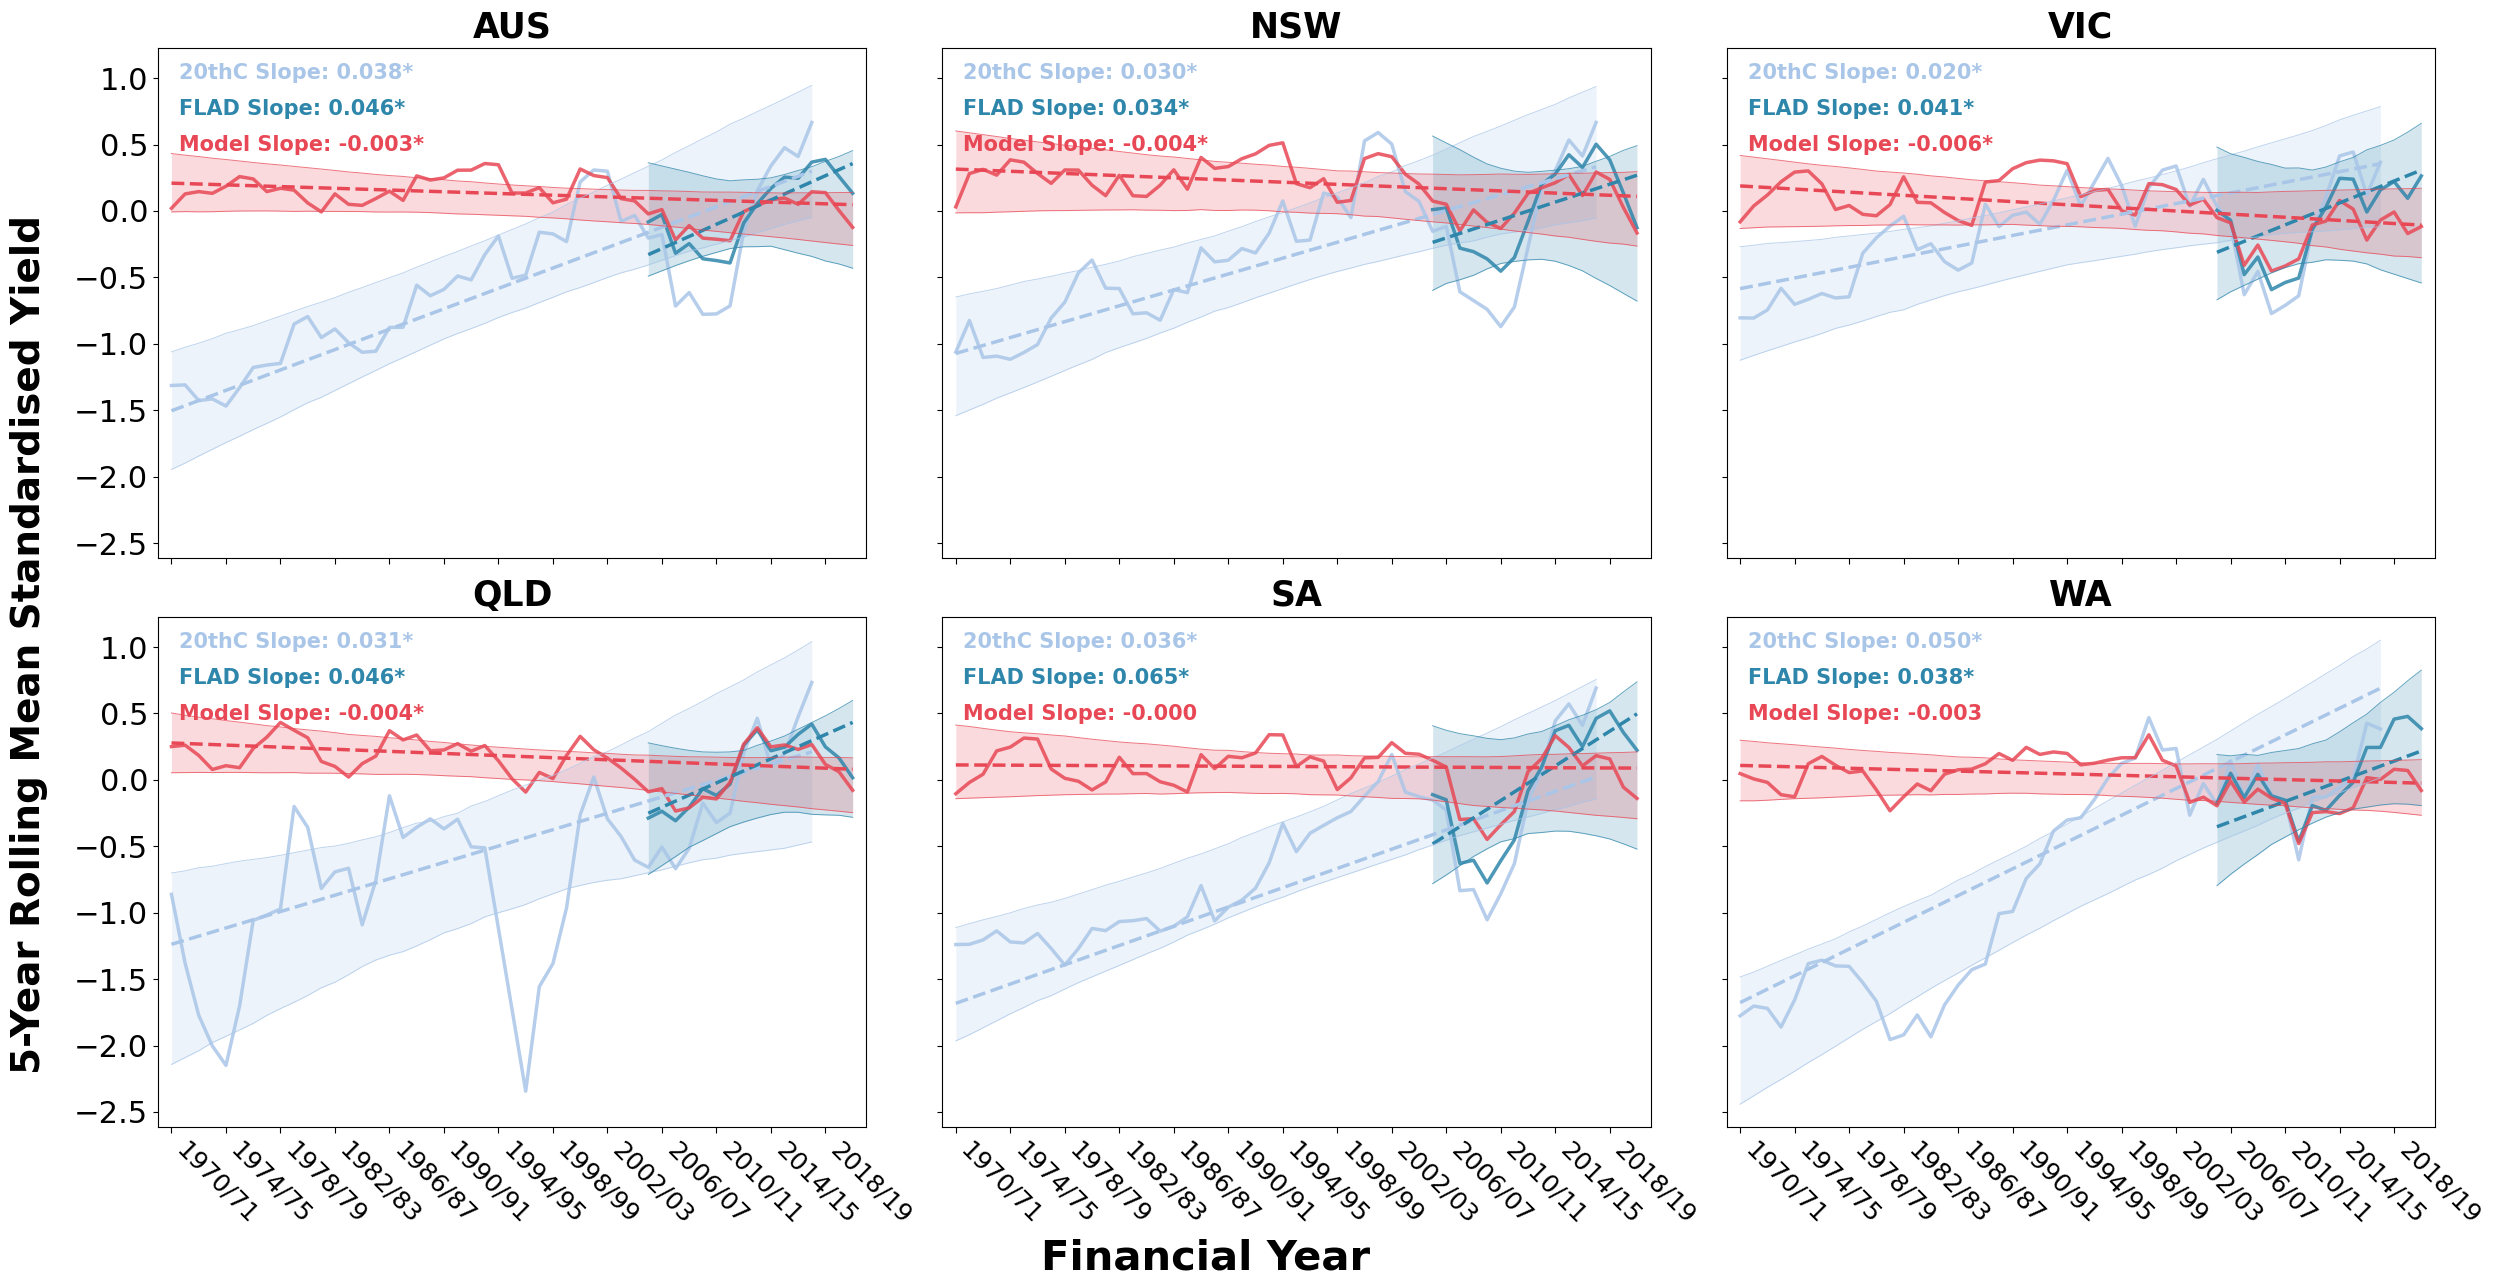

In [24]:
col_twent = "#A9C6E8"   # light blue - twentieth century obs
col_abs   = "#2E86AB"   # blue - obs (FLAD/ABS)
col_model = "#E84855"   # reddish - modelled

states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']
n_boot = 1000
full_years = np.arange(1970, 2020)

fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):
    twent_vals = twent_cent_subset[state].values
    twent_years = twent_cent_subset['year'].values
    abs_vals = ABS_subset[state].values
    abs_years = ABS_subset['year'].values
    model_vals = model_yield_plot[state].values
    model_years = model_yield_plot['year'].values

    tick_years = full_years[::4]
    tick_labels = [f"{y}/{str(y+1)[-2:]}" for y in tick_years]

    roll_years_twent, roll_vals_twent, slope_twent, intercept_twent, bs_twent, bi_twent = bootstrap_rolling_trend(
        twent_years, twent_vals, n_boot=n_boot, random_state=42, roll_center=False)
    roll_years_abs, roll_vals_abs, slope_abs, intercept_abs, bs_abs, bi_abs = bootstrap_rolling_trend(
        abs_years, abs_vals, n_boot=n_boot, random_state=42, roll_center=False)
    roll_years_model, roll_vals_model, slope_model, intercept_model, bs_model, bi_model = bootstrap_rolling_trend(
        model_years, model_vals, n_boot=n_boot, random_state=42, roll_center=False)

    sig_twent = mk.yue_wang_modification_test(roll_vals_twent).trend != "no trend"
    sig_abs = mk.yue_wang_modification_test(roll_vals_abs).trend != "no trend"
    sig_model = mk.yue_wang_modification_test(roll_vals_model).trend != "no trend"

    x_twent = np.arange(len(roll_years_twent))
    x_abs = np.arange(len(roll_years_abs))
    x_model = np.arange(len(roll_years_model))

    twent_trend, twent_lower, twent_upper = bootstrap_band(x_twent, slope_twent, intercept_twent, bs_twent, bi_twent)
    abs_trend, abs_lower, abs_upper = bootstrap_band(x_abs, slope_abs, intercept_abs, bs_abs, bi_abs)
    model_trend, model_lower, model_upper = bootstrap_band(x_model, slope_model, intercept_model, bs_model, bi_model)

    # observed series (rolling mean)
    ax.plot(roll_years_twent, roll_vals_twent, color=col_twent, linewidth=2.5, alpha=0.85)
    ax.plot(roll_years_abs, roll_vals_abs, color=col_abs, linewidth=2.5, alpha=0.85)
    ax.plot(roll_years_model, roll_vals_model, color=col_model, linewidth=2.5, alpha=0.85)

    # trendlines
    ax.plot(roll_years_twent, twent_trend, color=col_twent, linewidth=2.5, linestyle="--")
    ax.plot(roll_years_abs, abs_trend, color=col_abs, linewidth=2.5, linestyle="--")
    ax.plot(roll_years_model, model_trend, color=col_model, linewidth=2.5, linestyle="--")

    # uncertainty bands
    ax.fill_between(roll_years_twent, twent_lower, twent_upper, color=col_twent, alpha=0.2, linewidth=0)
    ax.fill_between(roll_years_abs, abs_lower, abs_upper, color=col_abs, alpha=0.2, linewidth=0)
    ax.fill_between(roll_years_model, model_lower, model_upper, color=col_model, alpha=0.2, linewidth=0)

    # thin band border lines
    ax.plot(roll_years_twent, twent_lower, color=col_twent, linewidth=0.7, alpha=0.75)
    ax.plot(roll_years_twent, twent_upper, color=col_twent, linewidth=0.7, alpha=0.75)
    ax.plot(roll_years_abs, abs_lower, color=col_abs, linewidth=0.7, alpha=0.75)
    ax.plot(roll_years_abs, abs_upper, color=col_abs, linewidth=0.7, alpha=0.75)
    ax.plot(roll_years_model, model_lower, color=col_model, linewidth=0.7, alpha=0.75)
    ax.plot(roll_years_model, model_upper, color=col_model, linewidth=0.7, alpha=0.75)

    sig_marker_twent = "*" if sig_twent else ""
    sig_marker_abs = "*" if sig_abs else ""
    sig_marker_model = "*" if sig_model else ""
    ax.text(0.03, 0.97, f"20thC Slope: {slope_twent:.3f}{sig_marker_twent}", color=col_twent,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.90, f"FLAD Slope: {slope_abs:.3f}{sig_marker_abs}", color=col_abs,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.83, f"Model Slope: {slope_model:.3f}{sig_marker_model}", color=col_model,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")

    ax.set_title(state, fontsize=25, fontweight="bold", pad=8)
    ax.set_xlim(1969, 2021)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=18)
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', which='both', length=4)

fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=30, fontweight="bold")
fig.text(0.04, 0.5, "5-Year Rolling Mean Standardised Yield",
         va='center', rotation='vertical', fontsize=28, fontweight="bold")
plt.tight_layout(rect=[0.07, 0.04, 1, 1])
plt.savefig("yield_timeseries_rolling_3series.png", dpi=300, bbox_inches="tight")
plt.show()

## Now with combined Observations

### Annual timeseries, annual trend

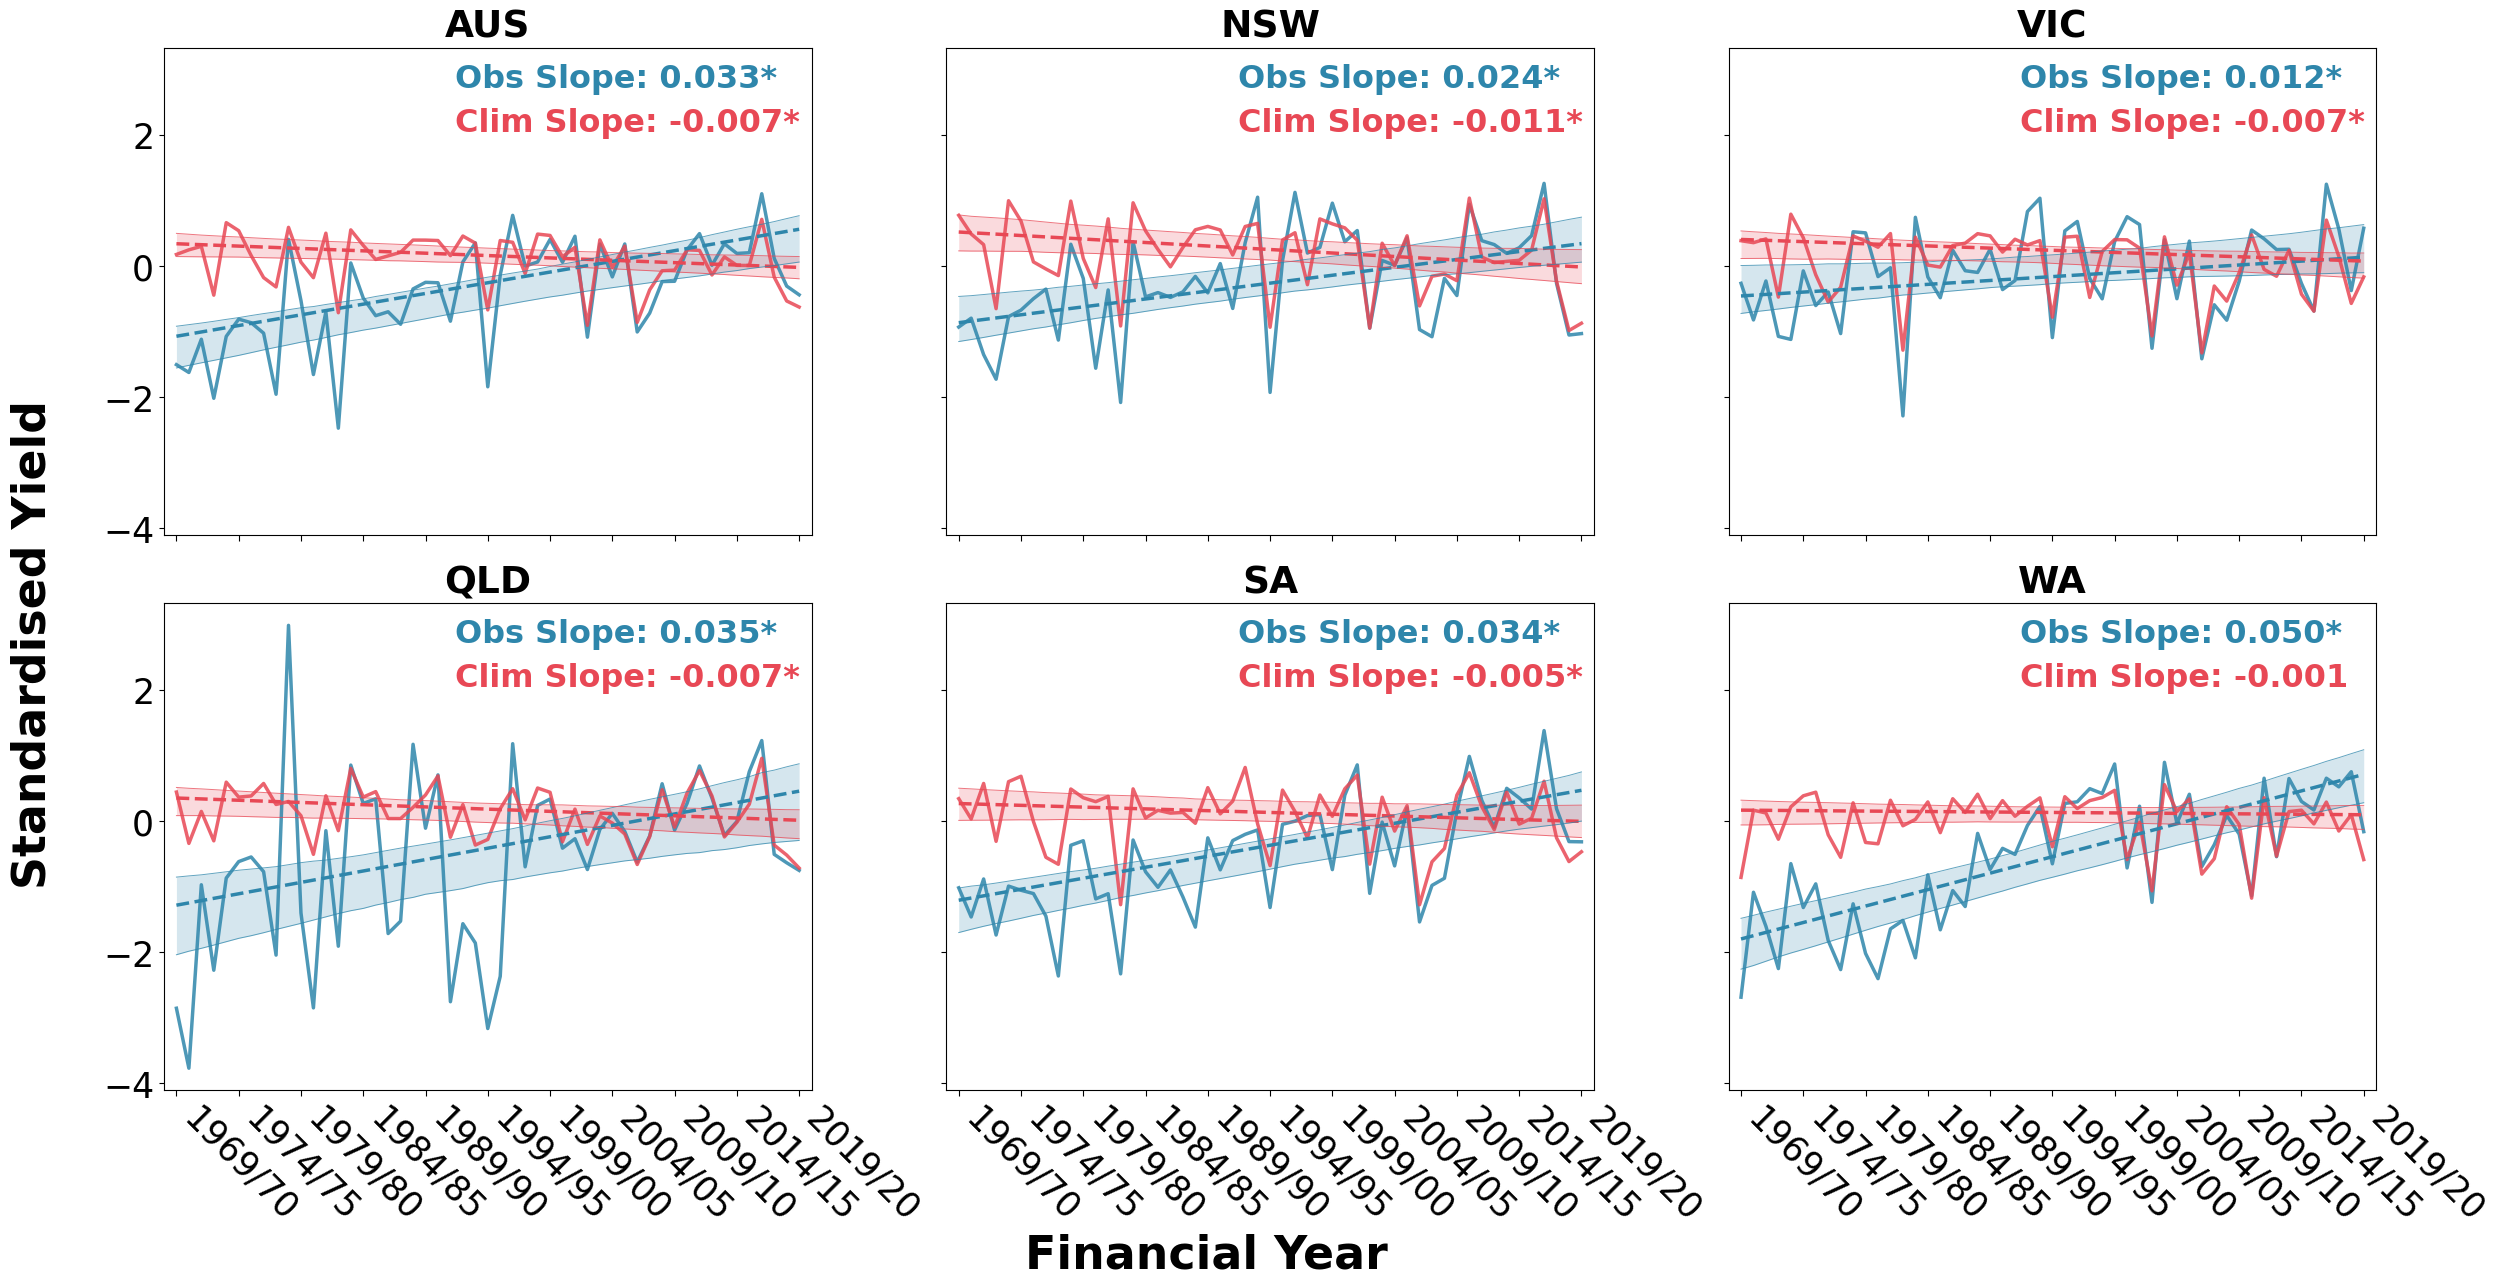

In [35]:
import matplotlib.transforms as mtransforms

col_obs   = "#2E86AB"   # blue - obs (FLAD/ABS)
col_model = "#E84855"   # reddish - modelled

states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']

n_boot = 1000
full_years = np.arange(1970, 2021)

fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):
    obs_yield_annual = obs_yield[obs_yield['year'] >= 1970]
    model_yield_plot_annual = model_yield_plot[model_yield_plot['year'] >= 1970]

    obs_vals = obs_yield_annual[state].values
    model_vals = model_yield_plot_annual[state].values

    obs_years = obs_yield_annual['year']
    model_years = model_yield_plot_annual['year']

    tick_years = full_years[::5]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

    slope_obs, intercept_obs, trend_obs, bs_obs, bi_obs = bootstrap_slope_intercept(
        obs_vals, n_boot=n_boot, random_state=42)
    slope_model, intercept_model, trend_model, bs_model, bi_model = bootstrap_slope_intercept(
        model_vals, n_boot=n_boot, random_state=42)

    sig_obs = trend_obs != "no trend"
    sig_model = trend_model != "no trend"

    x_obs = np.arange(len(obs_years))
    x_model = np.arange(len(model_years))

    obs_trend, obs_lower, obs_upper = bootstrap_band(x_obs, slope_obs, intercept_obs, bs_obs, bi_obs)
    model_trend, model_lower, model_upper = bootstrap_band(x_model, slope_model, intercept_model, bs_model, bi_model)

    # observed series
    ax.plot(obs_years, obs_vals, color=col_obs, linewidth=2.5, alpha=0.85)
    ax.plot(model_years, model_vals, color=col_model, linewidth=2.5, alpha=0.85)

    # trendlines
    ax.plot(obs_years, obs_trend, color=col_obs, linewidth=2.5, linestyle="--")
    ax.plot(model_years, model_trend, color=col_model, linewidth=2.5, linestyle="--")

    # bootstrap uncertainty bands (curved, direct percentile of bootstrapped lines)
    ax.fill_between(obs_years, obs_lower, obs_upper, color=col_obs, alpha=0.2, linewidth=0)
    ax.fill_between(model_years, model_lower, model_upper, color=col_model, alpha=0.2, linewidth=0)

    # thin border lines on the bands
    ax.plot(obs_years, obs_lower, color=col_obs, linewidth=0.7, alpha=0.75)
    ax.plot(obs_years, obs_upper, color=col_obs, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_lower, color=col_model, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_upper, color=col_model, linewidth=0.7, alpha=0.75)

    sig_marker_obs = "*" if sig_obs else ""
    sig_marker_model = "*" if sig_model else ""
    text_obs = f"Obs Slope: {slope_obs:.3f}{sig_marker_obs}"
    text_model = f"Clim Slope: {slope_model:.3f}{sig_marker_model}"

    ax.text(0.45, 0.97, text_obs, color=col_obs,
            fontsize=23, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.45, 0.88, text_model, color=col_model,
            fontsize=23, va="top", ha="left", transform=ax.transAxes, fontweight="bold")

    ax.set_title(state, fontsize=27, fontweight="bold", pad=8)
    ax.set_xlim(1969, 2021)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=25)
    offset = mtransforms.ScaledTranslation(-0.1, 0, fig.dpi_scale_trans)
    for label in ax.get_xticklabels():
        label.set_transform(label.get_transform() + offset)
    ax.tick_params(axis='y', labelsize=25)
    ax.tick_params(axis='x', which='both', length=4)

fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=33, fontweight="bold")
fig.text(0.04, 0.5, "Standardised Yield",
         va='center', rotation='vertical', fontsize=33, fontweight="bold")

plt.tight_layout(rect=[0.07, 0.04, 1, 1])

### Rolling timeseries, rolling trend (rolled, then bootstrapped)

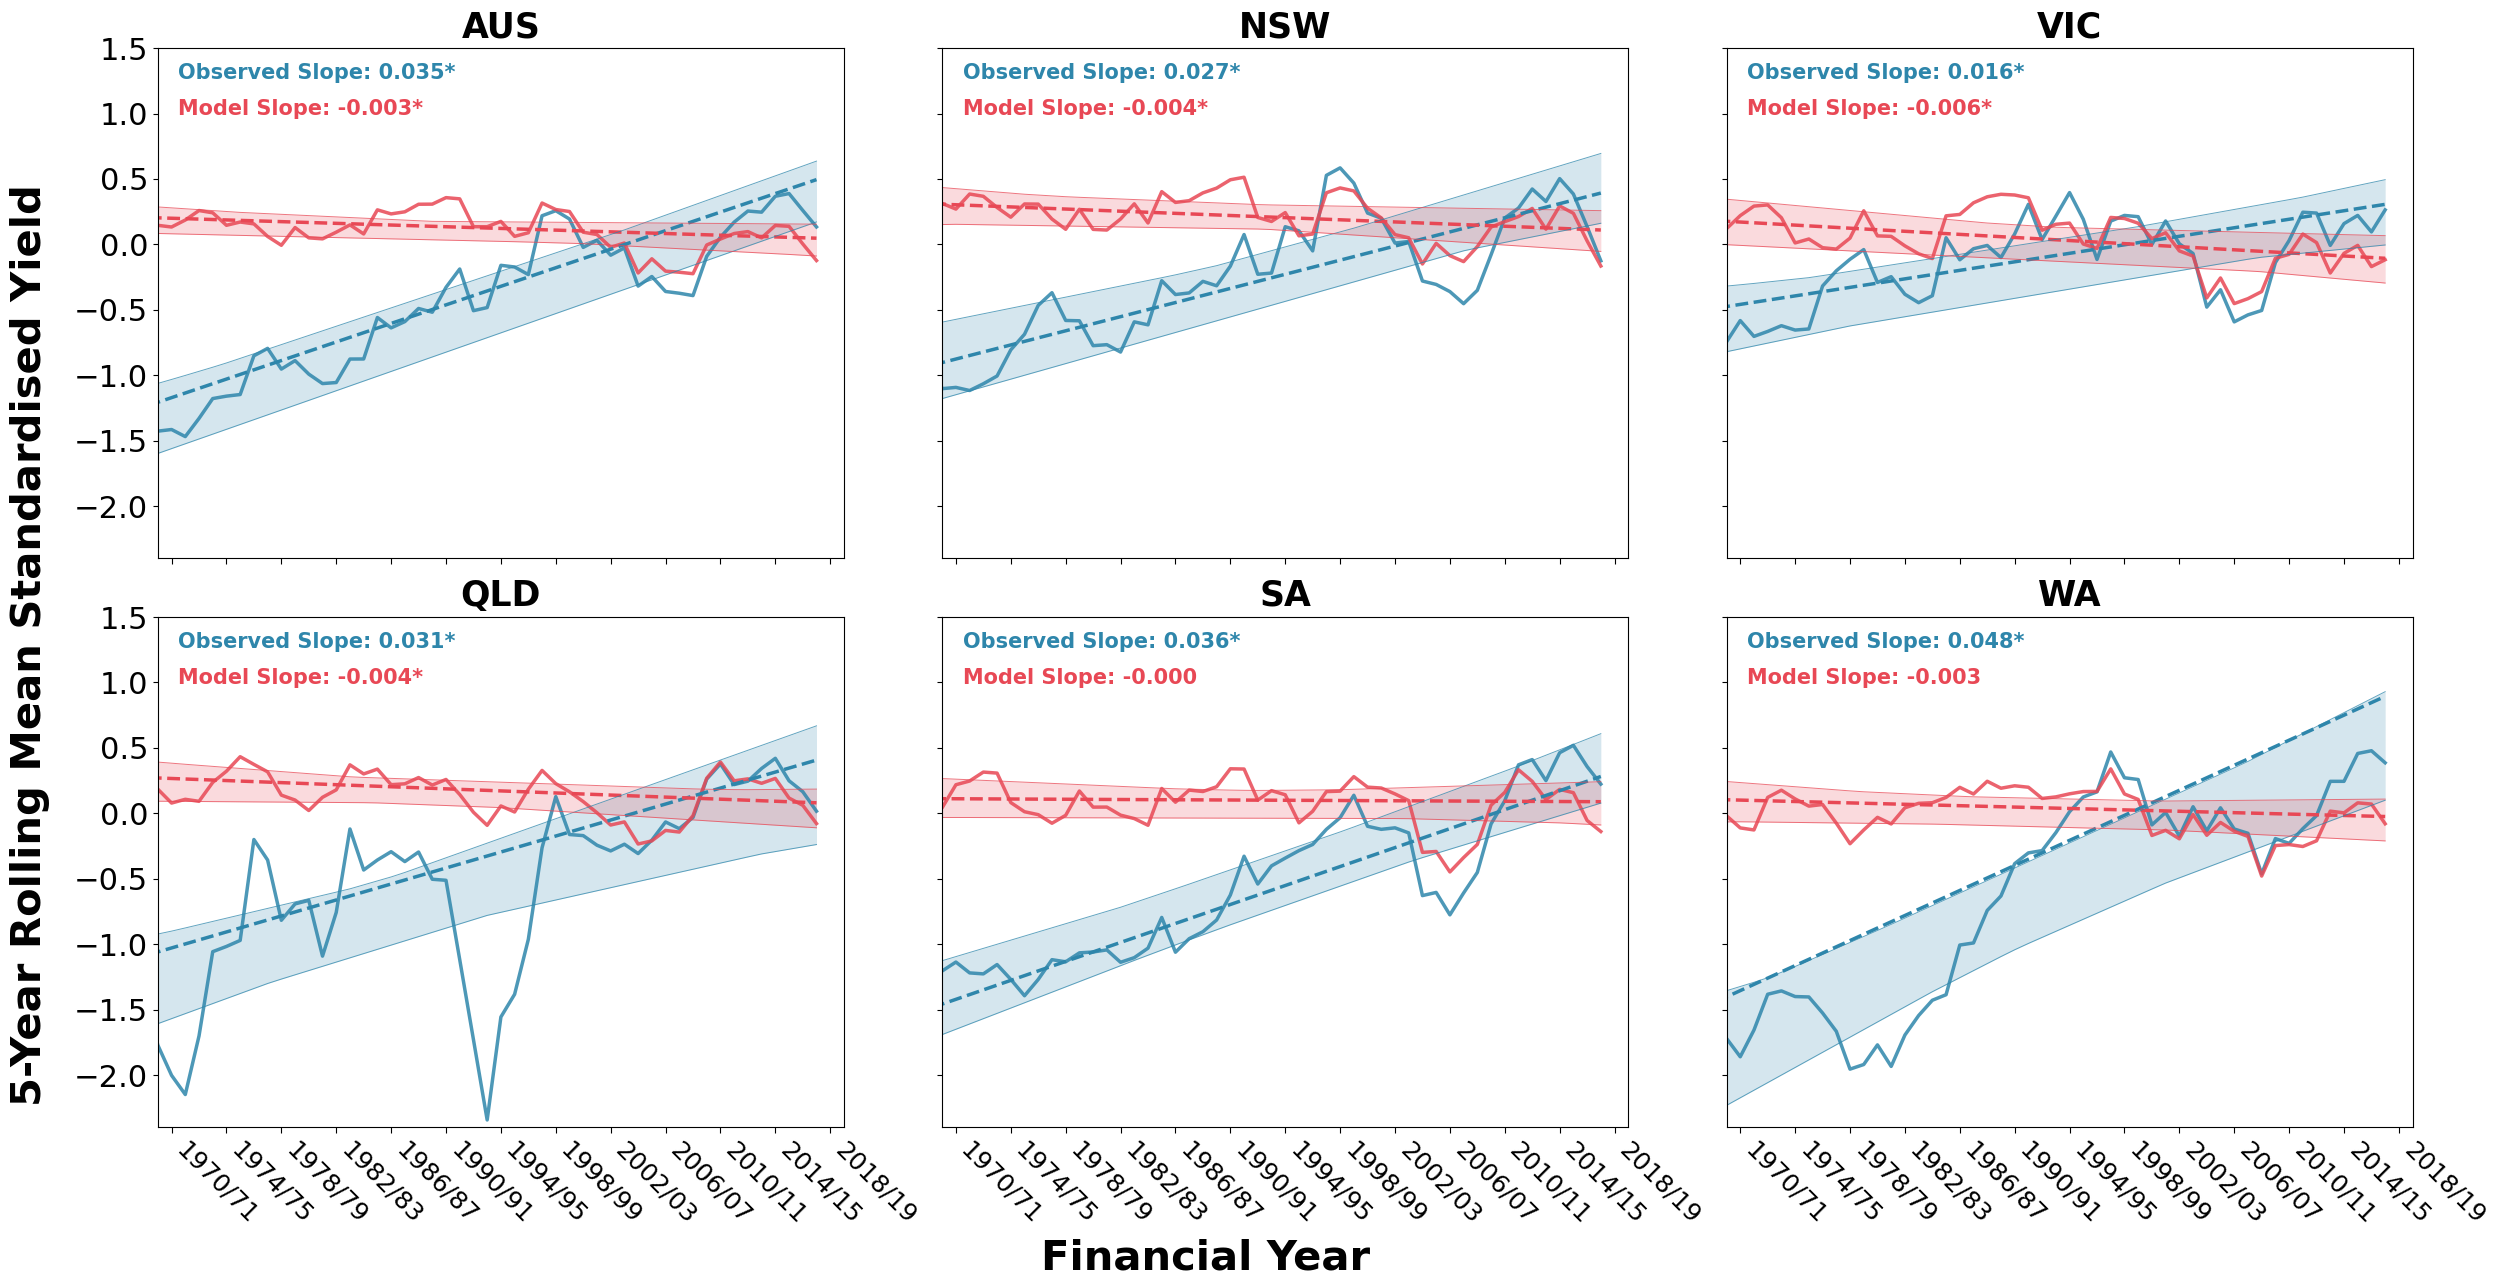

In [72]:
ROLL_WINDOW = 5
states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']

n_boot = 1000
full_years = np.arange(1971, 2021)

fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):
    obs_vals = obs_yield[state].values
    model_vals = model_yield_plot[state].values

    obs_years = obs_yield['year'].values
    model_years = model_yield_plot['year'].values

    # 5-year centered rolling mean, trimmed to valid (non-NaN) years
    obs_years_r, obs_vals_r = rolling_mean_series(obs_years, obs_vals)
    model_years_r, model_vals_r = rolling_mean_series(model_years, model_vals)

    tick_years = full_years[::4]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

    slope_obs, intercept_obs, trend_obs, bs_obs, bi_obs = bootstrap_slope_intercept(
        obs_vals_r, n_boot=n_boot, random_state=42)
    slope_model, intercept_model, trend_model, bs_model, bi_model = bootstrap_slope_intercept(
        model_vals_r, n_boot=n_boot, random_state=42)

    sig_obs = trend_obs != "no trend"
    sig_model = trend_model != "no trend"

    x_obs = np.arange(len(obs_years_r))
    x_model = np.arange(len(model_years_r))

    obs_trend, obs_lower, obs_upper = bootstrap_band(x_obs, slope_obs, intercept_obs, bs_obs, bi_obs, ci=100)
    model_trend, model_lower, model_upper = bootstrap_band(x_model, slope_model, intercept_model, bs_model, bi_model, ci=100)

    # rolling-mean series
    ax.plot(obs_years_r, obs_vals_r, color=col_obs, linewidth=2.5, alpha=0.85)
    ax.plot(model_years_r, model_vals_r, color=col_model, linewidth=2.5, alpha=0.85)

    # trendlines (fit on rolling-mean values)
    ax.plot(obs_years_r, obs_trend, color=col_obs, linewidth=2.5, linestyle="--")
    ax.plot(model_years_r, model_trend, color=col_model, linewidth=2.5, linestyle="--")

    # bootstrap uncertainty bands (curved, direct percentile of bootstrapped lines)
    ax.fill_between(obs_years_r, obs_lower, obs_upper, color=col_obs, alpha=0.2, linewidth=0)
    ax.fill_between(model_years_r, model_lower, model_upper, color=col_model, alpha=0.2, linewidth=0)

    # thin border lines on the bands
    ax.plot(obs_years_r, obs_lower, color=col_obs, linewidth=0.7, alpha=0.75)
    ax.plot(obs_years_r, obs_upper, color=col_obs, linewidth=0.7, alpha=0.75)
    ax.plot(model_years_r, model_lower, color=col_model, linewidth=0.7, alpha=0.75)
    ax.plot(model_years_r, model_upper, color=col_model, linewidth=0.7, alpha=0.75)

    sig_marker_obs = "*" if sig_obs else ""
    sig_marker_model = "*" if sig_model else ""
    text_obs = f"Observed Slope: {slope_obs:.3f}{sig_marker_obs}"
    text_model = f"Model Slope: {slope_model:.3f}{sig_marker_model}"

    ax.text(0.03, 0.97, text_obs, color=col_obs,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.90, text_model, color=col_model,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")

    ax.set_title(state, fontsize=25, fontweight="bold", pad=8)
    ax.set_xlim(1970, 2020)
    ax.set_ylim(-2.4, 1.5)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=18)
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', which='both', length=4)

fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=30, fontweight="bold")
fig.text(0.04, 0.5, f"{ROLL_WINDOW}-Year Rolling Mean Standardised Yield",
         va='center', rotation='vertical', fontsize=30, fontweight="bold")

plt.tight_layout(rect=[0.07, 0.04, 1, 1])
plt.show()

### Rolling timeseries, annual trend

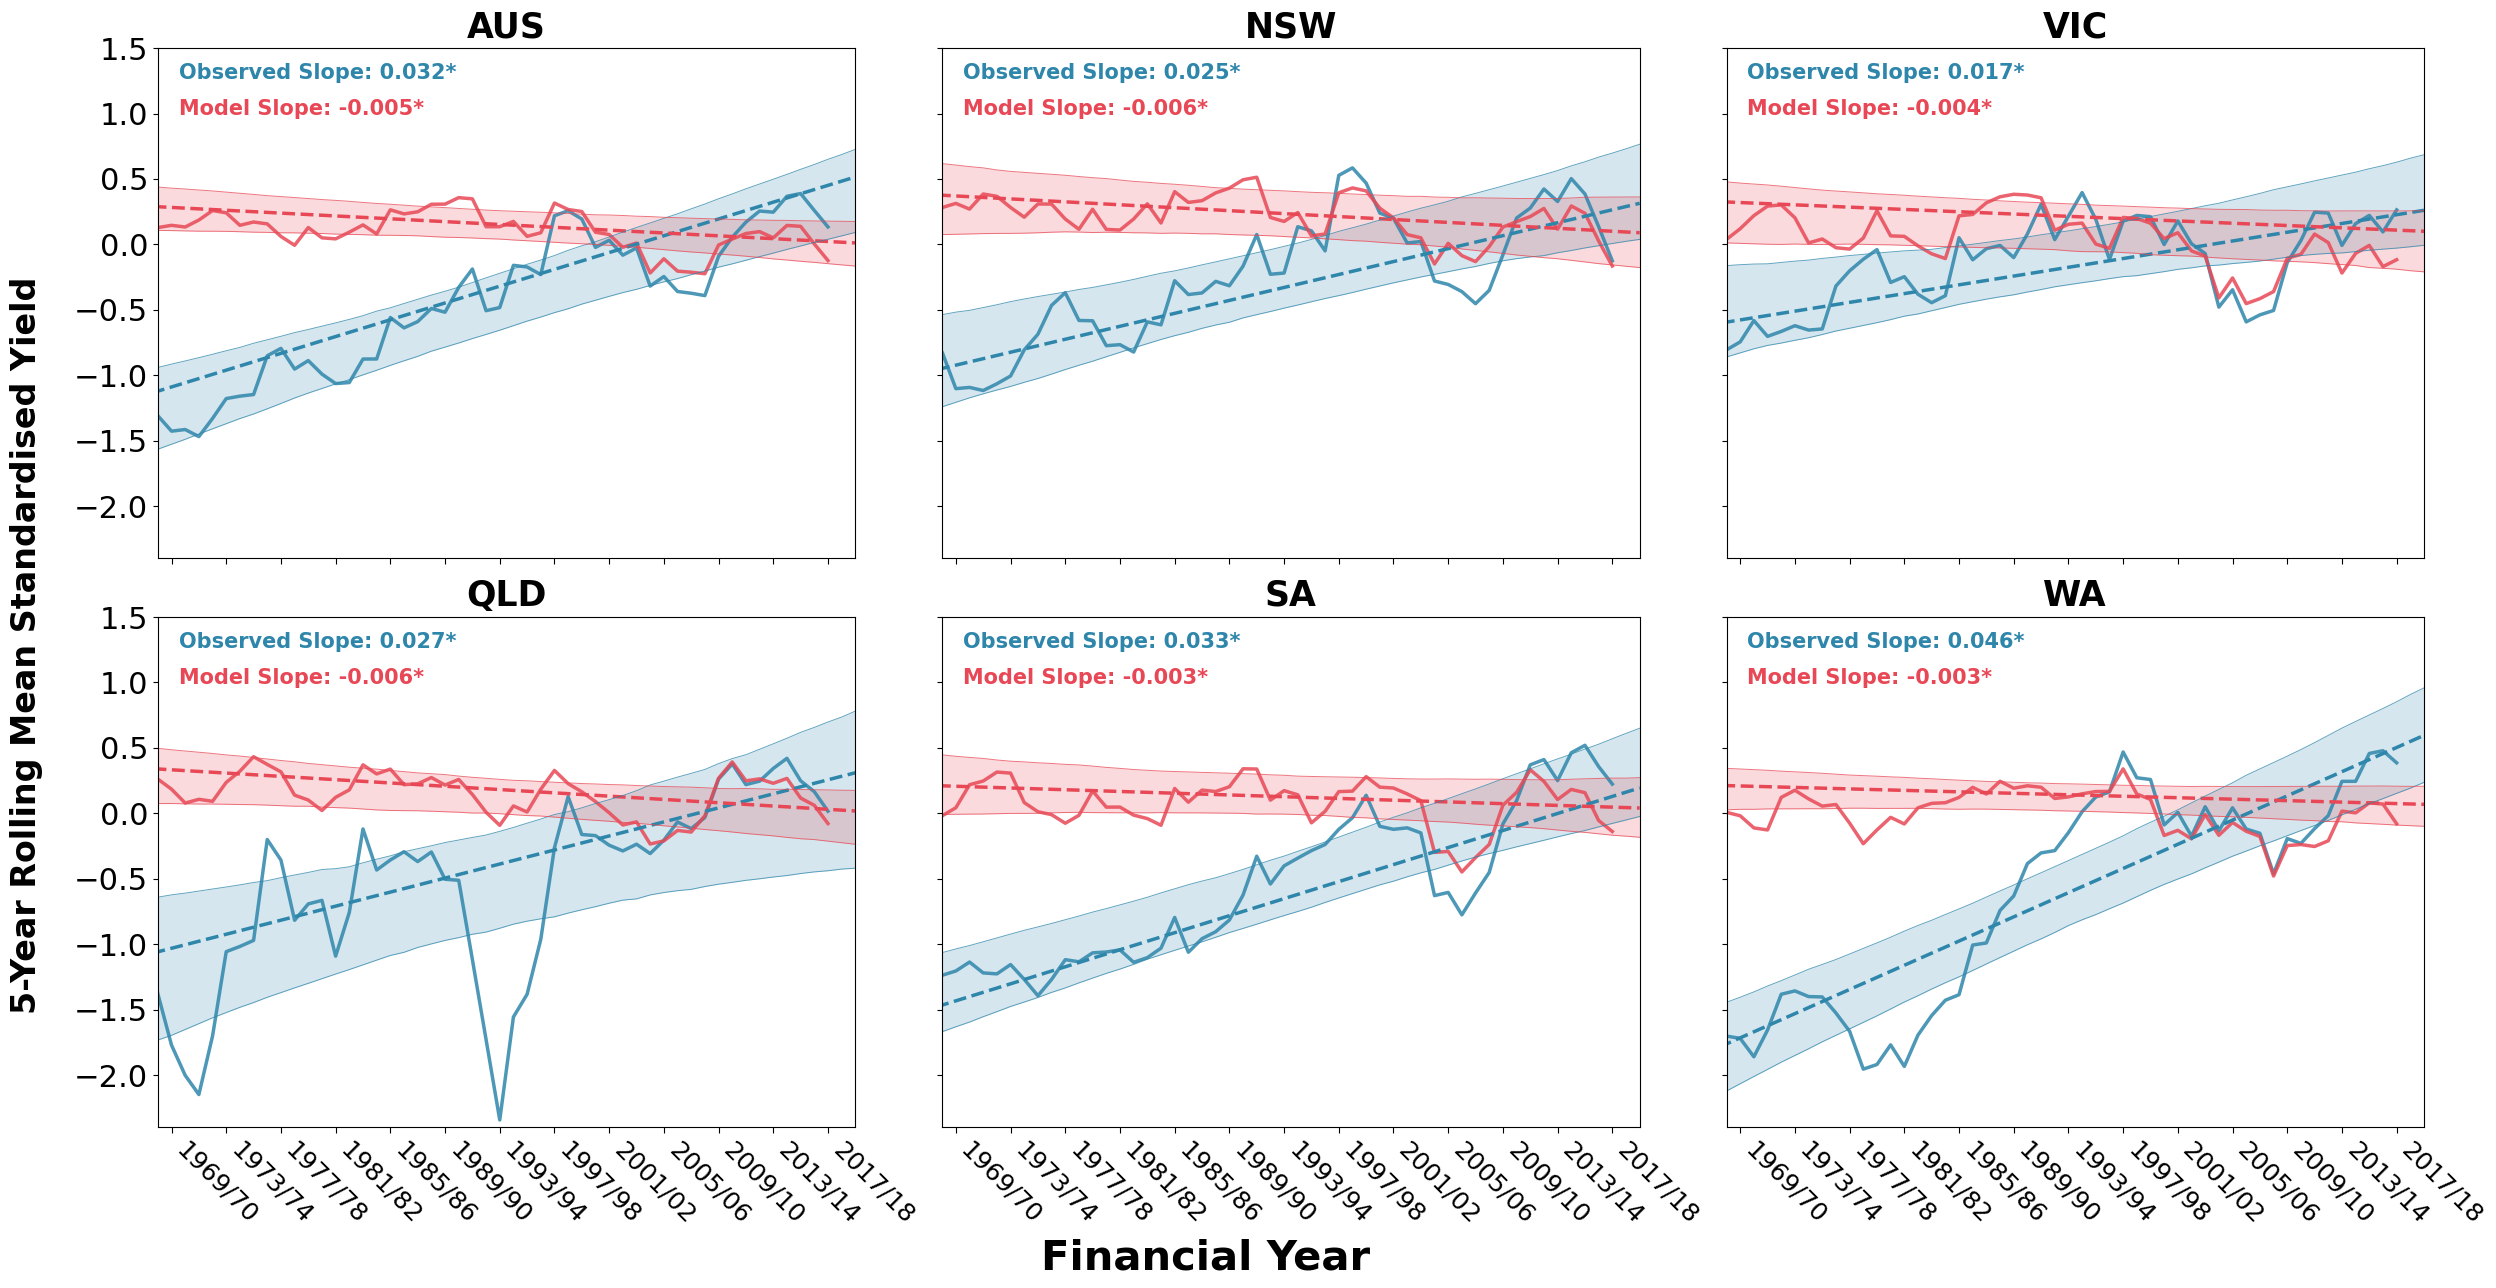

In [73]:
states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']

n_boot = 1000
full_years = np.arange(1970, 2020)

fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):
    obs_vals = obs_yield[state].values
    model_vals = model_yield_plot[state].values

    obs_years = obs_yield['year'].values
    model_years = model_yield_plot['year'].values

    # 5-year rolling mean -- for the DISPLAYED observed line only
    obs_years_r, obs_vals_r = rolling_mean_series(obs_years, obs_vals)
    model_years_r, model_vals_r = rolling_mean_series(model_years, model_vals)

    tick_years = full_years[::4]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

    # trend + bootstrap fit on the RAW annual data (not the rolling mean)
    slope_obs, intercept_obs, trend_obs, bs_obs, bi_obs = bootstrap_slope_intercept(
        obs_vals, n_boot=n_boot, random_state=42)
    slope_model, intercept_model, trend_model, bs_model, bi_model = bootstrap_slope_intercept(
        model_vals, n_boot=n_boot, random_state=42)

    sig_obs = trend_obs != "no trend"
    sig_model = trend_model != "no trend"

    x_obs = np.arange(len(obs_years))
    x_model = np.arange(len(model_years))

    obs_trend, obs_lower, obs_upper = bootstrap_band(x_obs, slope_obs, intercept_obs, bs_obs, bi_obs)
    model_trend, model_lower, model_upper = bootstrap_band(x_model, slope_model, intercept_model, bs_model, bi_model)

    # observed series -- rolling mean, smoothed for display
    ax.plot(obs_years_r, obs_vals_r, color=col_obs, linewidth=2.5, alpha=0.85)
    ax.plot(model_years_r, model_vals_r, color=col_model, linewidth=2.5, alpha=0.85)

    # trendlines -- fit on raw annual years, plotted over the full raw year range
    ax.plot(obs_years, obs_trend, color=col_obs, linewidth=2.5, linestyle="--")
    ax.plot(model_years, model_trend, color=col_model, linewidth=2.5, linestyle="--")

    # bootstrap uncertainty bands -- also over raw annual years
    ax.fill_between(obs_years, obs_lower, obs_upper, color=col_obs, alpha=0.2, linewidth=0)
    ax.fill_between(model_years, model_lower, model_upper, color=col_model, alpha=0.2, linewidth=0)

    # thin border lines on the bands
    ax.plot(obs_years, obs_lower, color=col_obs, linewidth=0.7, alpha=0.75)
    ax.plot(obs_years, obs_upper, color=col_obs, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_lower, color=col_model, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_upper, color=col_model, linewidth=0.7, alpha=0.75)

    sig_marker_obs = "*" if sig_obs else ""
    sig_marker_model = "*" if sig_model else ""
    text_obs = f"Observed Slope: {slope_obs:.3f}{sig_marker_obs}"
    text_model = f"Model Slope: {slope_model:.3f}{sig_marker_model}"

    ax.text(0.03, 0.97, text_obs, color=col_obs,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.90, text_model, color=col_model,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")

    ax.set_title(state, fontsize=25, fontweight="bold", pad=8)
    ax.set_xlim(1969, 2020)
    ax.set_ylim(-2.4, 1.5)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=18)
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', which='both', length=4)

fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=30, fontweight="bold")
fig.text(0.04, 0.5, f"{ROLL_WINDOW}-Year Rolling Mean Standardised Yield",
         va='center', rotation='vertical', fontsize=24, fontweight="bold")

plt.tight_layout(rect=[0.07, 0.04, 1, 1])
plt.show()

### Rolling timeseries, rolling trend (bootrapped, then rolled)

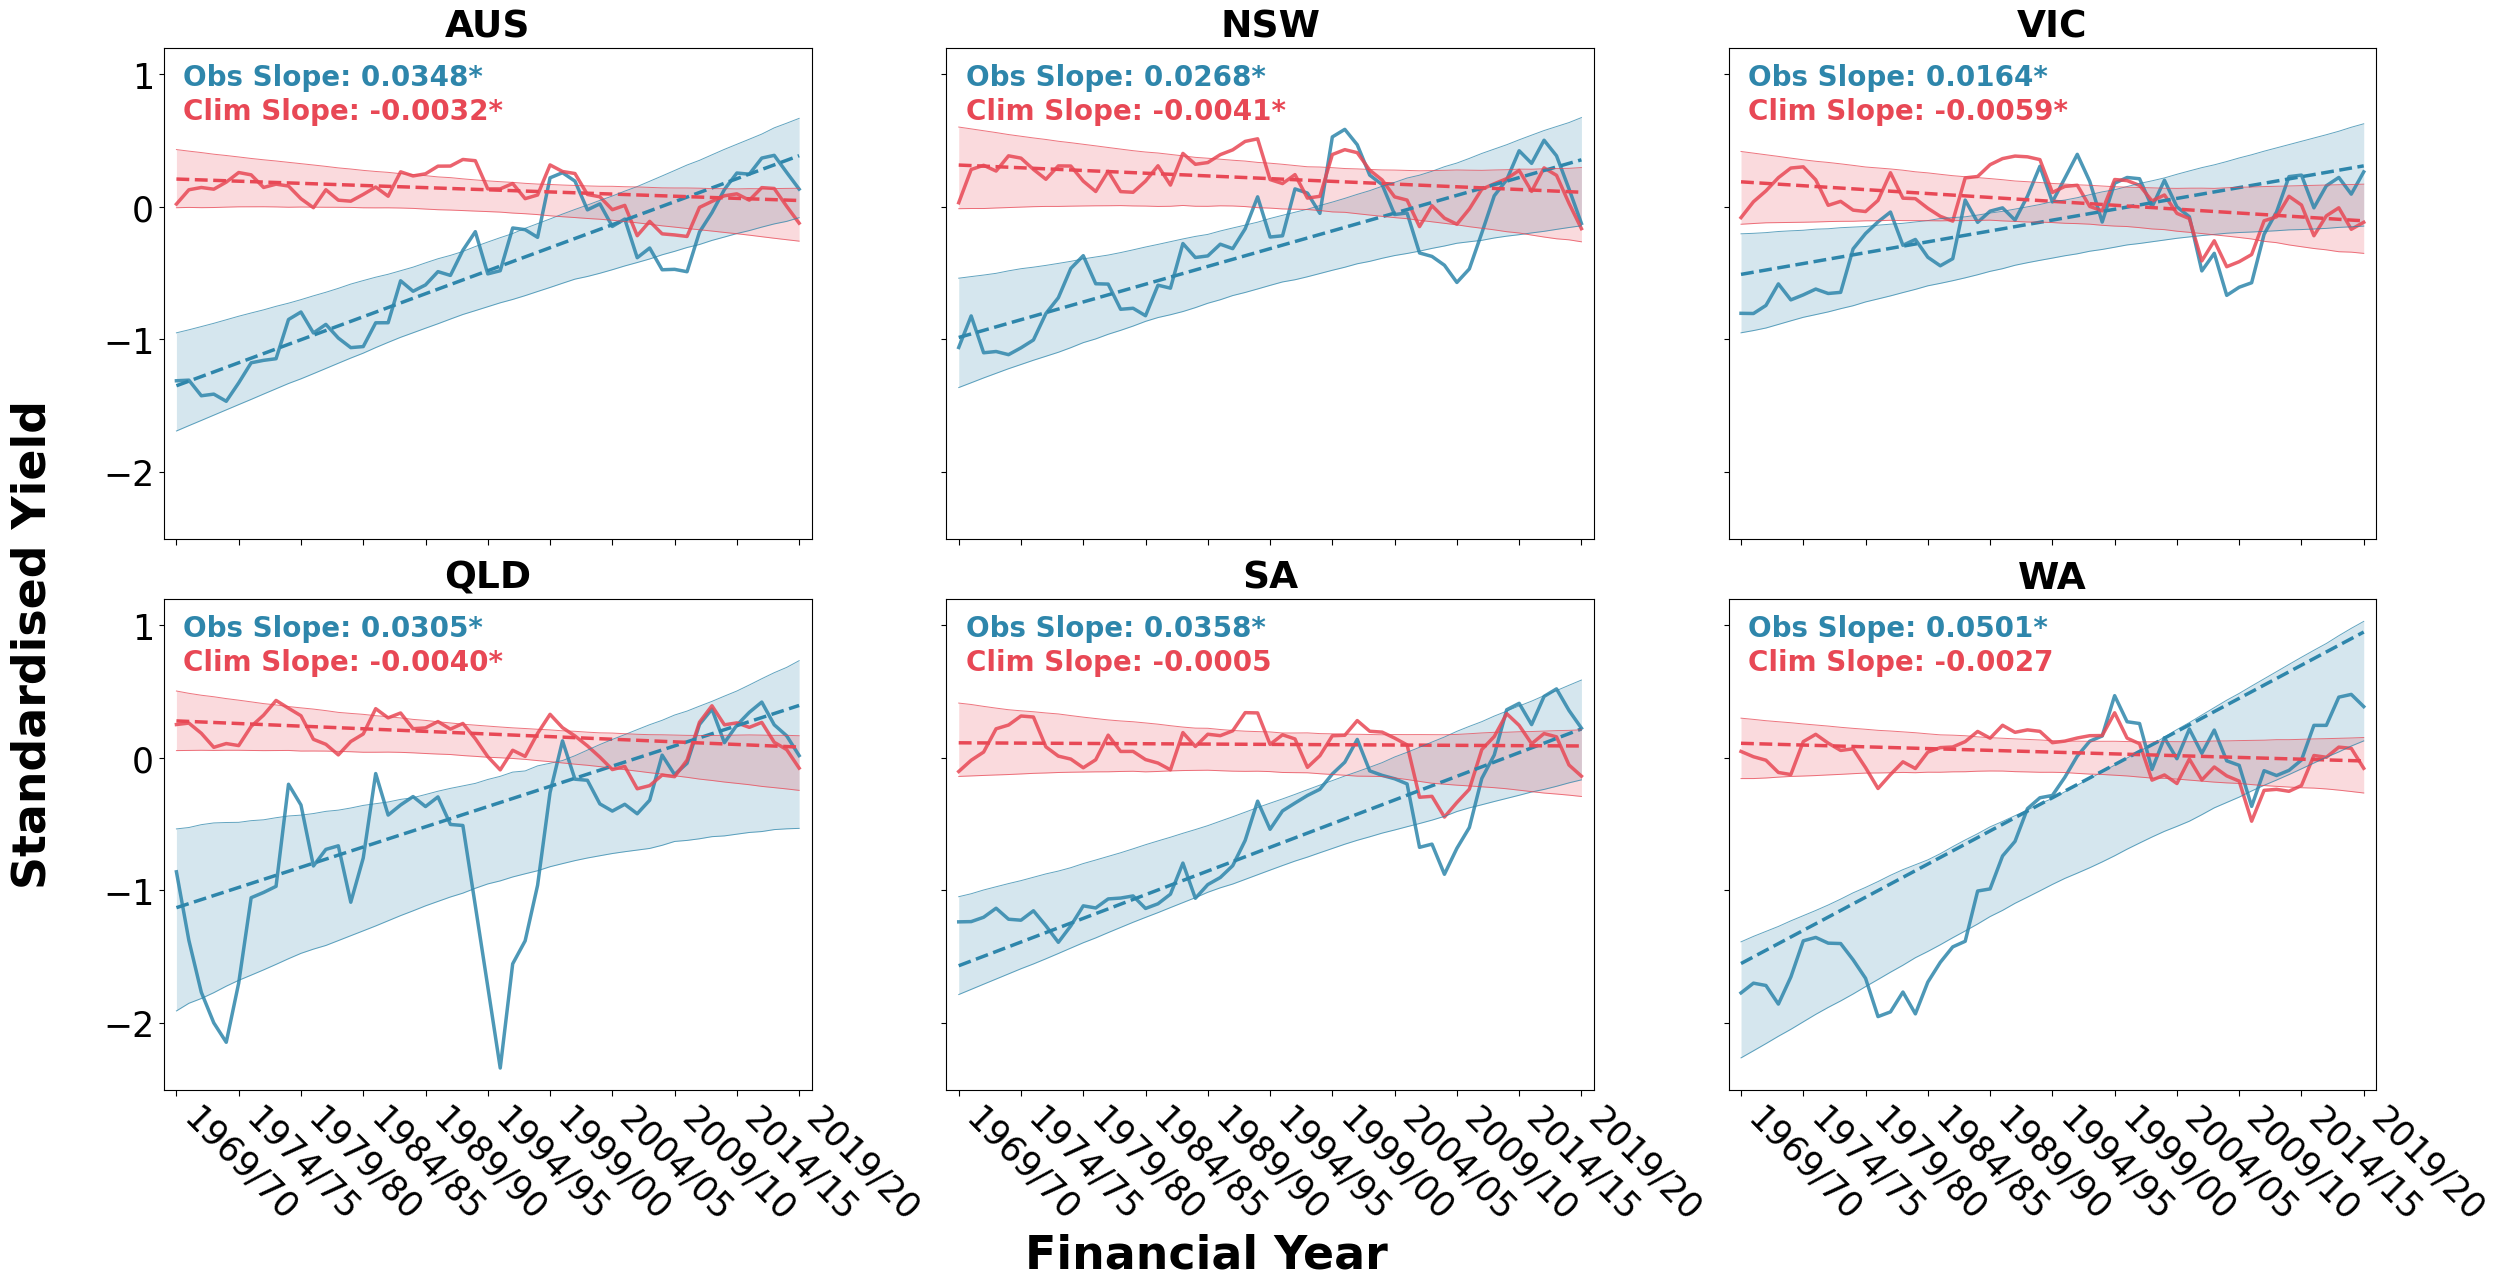

In [ ]:
import matplotlib.transforms as mtransforms


col_obs   = "#2E86AB"   # blue - combined observed (20thC + FLAD)
col_model = "#E84855"   # reddish - modelled

obs_yield = pd.concat([twent_cent_subset, ABS_subset], ignore_index=True)
obs_yield = obs_yield.sort_values('year').drop_duplicates(subset='year', keep='last').reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

full_years = np.arange(1970, 2021)
for ax, state in zip(axes, states):
    obs_vals = obs_yield[state].values
    obs_years = obs_yield['year'].values
    model_vals = model_yield_plot[state].values
    model_years = model_yield_plot['year'].values

    tick_years = full_years[::5]
    tick_labels = [f"{str(y-1)}/{str(y)[-2:]}" for y in tick_years]

    roll_years_obs, roll_vals_obs, slope_obs, intercept_obs, bs_obs, bi_obs = bootstrap_rolling_trend(
        obs_years, obs_vals, n_boot=n_boot, random_state=42, roll_center=False)
    roll_years_model, roll_vals_model, slope_model, intercept_model, bs_model, bi_model = bootstrap_rolling_trend(
        model_years, model_vals, n_boot=n_boot, random_state=42, roll_center=False)

    sig_obs = mk.yue_wang_modification_test(roll_vals_obs).trend != "no trend"
    sig_model = mk.yue_wang_modification_test(roll_vals_model).trend != "no trend"

    x_obs = np.arange(len(roll_years_obs))
    x_model = np.arange(len(roll_years_model))

    obs_trend, obs_lower, obs_upper = bootstrap_band(x_obs, slope_obs, intercept_obs, bs_obs, bi_obs)
    model_trend, model_lower, model_upper = bootstrap_band(x_model, slope_model, intercept_model, bs_model, bi_model)

    ax.plot(roll_years_obs, roll_vals_obs, color=col_obs, linewidth=2.5, alpha=0.85)
    ax.plot(roll_years_model, roll_vals_model, color=col_model, linewidth=2.5, alpha=0.85)

    ax.plot(roll_years_obs, obs_trend, color=col_obs, linewidth=2.5, linestyle="--")
    ax.plot(roll_years_model, model_trend, color=col_model, linewidth=2.5, linestyle="--")

    ax.fill_between(roll_years_obs, obs_lower, obs_upper, color=col_obs, alpha=0.2, linewidth=0)
    ax.fill_between(roll_years_model, model_lower, model_upper, color=col_model, alpha=0.2, linewidth=0)

    ax.plot(roll_years_obs, obs_lower, color=col_obs, linewidth=0.7, alpha=0.75)
    ax.plot(roll_years_obs, obs_upper, color=col_obs, linewidth=0.7, alpha=0.75)
    ax.plot(roll_years_model, model_lower, color=col_model, linewidth=0.7, alpha=0.75)
    ax.plot(roll_years_model, model_upper, color=col_model, linewidth=0.7, alpha=0.75)

    sig_marker_obs = "*" if sig_obs else ""
    sig_marker_model = "*" if sig_model else ""
    # if f'{slope_obs:.3f}'[-1] == "0":
    #     slope_obs
    ax.text(0.03, 0.97, f"Obs Slope: {slope_obs:.4f}{sig_marker_obs}", color=col_obs,
            fontsize=20, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.90, f"Clim Slope: {slope_model:.4f}{sig_marker_model}", color=col_model,
            fontsize=20, va="top", ha="left", transform=ax.transAxes, fontweight="bold")

    ax.set_title(state, fontsize=27, fontweight="bold", pad=8)
    ax.set_xlim(1969, 2021)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=25)
    offset = mtransforms.ScaledTranslation(-0.05, 0, fig.dpi_scale_trans)
    for label in ax.get_xticklabels():
        label.set_transform(label.get_transform() + offset)
    ax.tick_params(axis='y', labelsize=25)
    ax.tick_params(axis='x', which='both', length=4)

fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=33, fontweight="bold")
fig.text(0.04, 0.5, "Standardised Yield",
         va='center', rotation='vertical', fontsize=33, fontweight="bold")
plt.tight_layout(rect=[0.07, 0.04, 1, 1])
# plt.savefig("yield_timeseries_rolling_2series.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from scipy.stats import norm

def sen_slope_ci(x, var_s, alpha=0.05):
    """
    Compute confidence interval for Sen's slope estimator (Gilbert, 1987).
    x: 1D array of values (e.g. true_vals or pred_vals)
    var_s: variance of S statistic, from pymannkendall result (mk_result.var_s)
    alpha: significance level (default 0.05 -> 95% CI)
    """
    n = len(x)
    slopes = []
    for i in range(n - 1):
        for j in range(i + 1, n):
            slopes.append((x[j] - x[i]) / (j - i))
    slopes = np.sort(np.array(slopes))
    N = len(slopes)

    z = norm.ppf(1 - alpha / 2)
    C_alpha = z * np.sqrt(var_s)

    M1 = int(np.floor((N - C_alpha) / 2))
    M2 = int(np.ceil((N + C_alpha) / 2)) + 1

    M1 = max(M1, 0)
    M2 = min(M2, N - 1)

    lower_slope = slopes[M1]
    upper_slope = slopes[M2]

    return lower_slope, upper_slope

NameError: name 'sen_slope_ci' is not defined

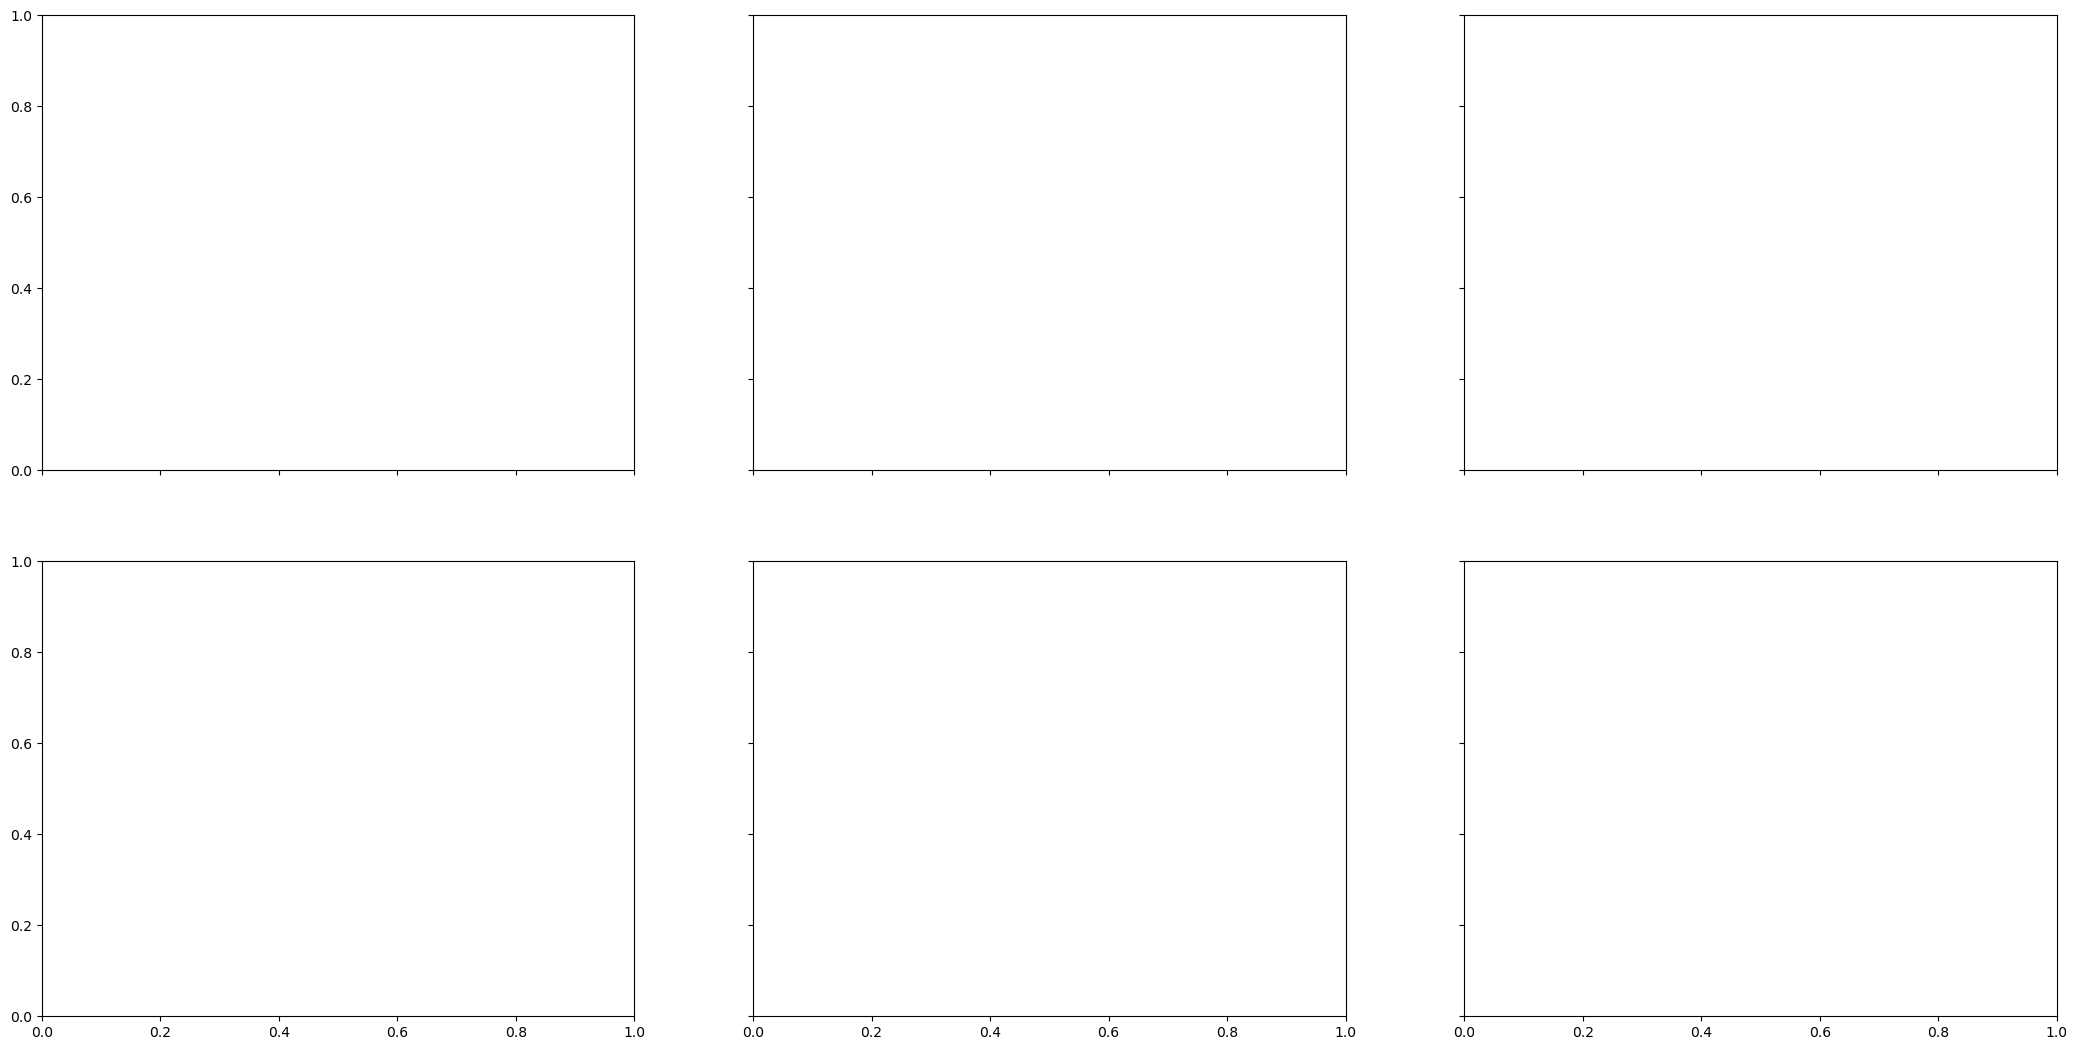

In [24]:
# Cool scientific palette
col_true = "#2E86AB"   # teal
col_pred = "#E84855"   # coral

states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']
fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):
    obs_state = obs_yield[state]
    model_state = model_yield_plot[state]
    years_sorted = np.sort(np.unique(obs_yield['year']))
    tick_years = years_sorted[::2]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

    mk_obs = mk.yue_wang_modification_test(obs_state.values)
    mk_model = mk.yue_wang_modification_test(model_state.values)
    slope_obs = mk_obs.slope
    slope_model = mk_model.slope
    intercept_obs = mk_obs.intercept
    intercept_model = mk_model.intercept

    sig_obs = mk_obs.trend != "no trend"
    sig_model = mk_model.trend != "no trend"
    obs_trendline = slope_obs * np.arange(len(obs_yield['year'])) + intercept_obs
    model_trendline = slope_model * np.arange(len(model_yield_plot['year'])) + intercept_model


    lower_slope_true, upper_slope_true = sen_slope_ci(obs_state, mk_obs.var_s)
    lower_slope_pred, upper_slope_pred = sen_slope_ci(model_state, mk_model.var_s)

    x_arange = np.arange(len(obs_yield['year']))
    x_median = np.median(x_arange)

    median_true = np.median(obs_state)
    median_pred = np.median(model_state)

    # Median trend line, pivoted through (x_median, median value) -- equivalent to Sen's slope line
    true_trend = median_true + slope_obs * (x_arange - x_median)
    pred_trend = median_pred + slope_model * (x_arange - x_median)

    # Bounds pivot through the same point, fanning outwards in both directions
    lower_trend_true = median_true + lower_slope_true * (x_arange - x_median)
    upper_trend_true = median_true + upper_slope_true * (x_arange - x_median)
    lower_trend_pred = median_pred + lower_slope_pred * (x_arange - x_median)
    upper_trend_pred = median_pred + upper_slope_pred * (x_arange - x_median)

    # lower_trend_true = lower_slope_true * x_arange + intercept_true
    # upper_trend_true = upper_slope_true * x_arange + intercept_true
    # lower_trend_pred = lower_slope_pred * x_arange + intercept_pred
    # upper_trend_pred = upper_slope_pred * x_arange + intercept_pred   

    # true_trend = slope_true * np.arange(len(years)) + intercept_true
    # pred_trend = slope_pred * np.arange(len(years)) + intercept_pred

    ax.plot(obs_yield['year'], obs_state, color=col_true, linewidth=2.5, alpha=0.85)
    ax.plot(model_yield_plot['year'], model_state, color=col_pred, linewidth=2.5, alpha=0.85)

    ax.plot(model_yield_plot['year'], true_trend, color=col_true, linewidth=2.5, linestyle="--")
    ax.plot(model_yield_plot['year'], pred_trend, color=col_pred, linewidth=2.5, linestyle="--")


    ax.fill_between(model_yield_plot['year'], lower_trend_true, upper_trend_true,
                     color=col_true, alpha=0.15, linewidth=0)
    ax.fill_between(model_yield_plot['year'], lower_trend_pred, upper_trend_pred,
                     color=col_pred, alpha=0.15, linewidth=0)
    
    # Thin solid lines marking the CI bounds
    ax.plot(model_yield_plot['year'], lower_trend_true, color=col_true, linewidth=0.7, alpha=0.75)
    ax.plot(model_yield_plot['year'], upper_trend_true, color=col_true, linewidth=0.7, alpha=0.75)
    ax.plot(model_yield_plot['year'], lower_trend_pred, color=col_pred, linewidth=0.7, alpha=0.75)
    ax.plot(model_yield_plot['year'], upper_trend_pred, color=col_pred, linewidth=0.7, alpha=0.75)
    
    sig_marker_true = "*" if sig_obs else ""
    sig_marker_pred = "*" if sig_model else ""
    text_true = f"Obs Slope: {sig_obs:.3f}{sig_marker_true}"
    text_pred = f"Clim Slope: {slope_model:.3f}{sig_marker_pred}"
    # if state == 'QLD':
    #     text_y = [0.2, 0.13]
    # else:
    text_y = [0.97, 0.9]
    ax.text(0.03, text_y[0], text_true, color=col_true,
            fontsize=18, va="top", ha="left", transform=ax.transAxes,
            fontweight="bold")
    ax.text(0.03, text_y[1], text_pred, color=col_pred,
            fontsize=18, va="top", ha="left", transform=ax.transAxes,
            fontweight="bold")

    ax.set_title(state, fontsize=25, fontweight="bold", pad=8)

    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=22)
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', which='both', length=4)

# Shared axis labels
fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=30, fontweight="bold")
fig.text(0.04, 0.5, "Standardised Yield",
         va='center', rotation='vertical', fontsize=30, fontweight="bold")

plt.tight_layout(rect=[0.07, 0.04, 1, 1])
# plt.savefig("yield_trends_publication.pdf", dpi=300, bbox_inches="tight")
plt.show()